# Setup

In [1]:
# !git clone --quiet https://github.com/vlad-yeghiazaryan/IMF_api.git
# !git clone --quiet https://github.com/vlad-yeghiazaryan/tradingView-websocket-api.git
# !git clone --quiet https://github.com/vlad-yeghiazaryan/data-extensions.git
# !pip install -q wbgapi
# !mv tradingView-websocket-api/TView_api.py .
# !mv data-extensions/imputation/panel_imputation.py .

In [2]:
# importing main libs
import sys
from functools import reduce
import numpy as np
import pandas as pd
import re
from scipy import signal
from scipy.stats import norm
import operator

# libs for plots
import matplotlib.pyplot as plt
import seaborn as sns

# models
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.experimental import enable_iterative_imputer
enable_iterative_imputer
from sklearn.impute import IterativeImputer

# preprocessing, feature and model selection
from sklearn.base import BaseEstimator, TransformerMixin
from feature_engine.timeseries.forecasting import LagFeatures
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import make_column_selector as selector, ColumnTransformer
from sklearn.pipeline import Pipeline

# nlp
import nltk
from nltk.corpus import stopwords
from thefuzz import fuzz
nltk.download('stopwords')

# util
from IPython.display import display
from warnings import simplefilter
simplefilter(action="ignore", category=pd.errors.PerformanceWarning)

# other libraries
sys.path.append("./tradingView-websocket-api")
sys.path.append("./data-extensions/imputation")
import wbgapi as wb
import yfinance as yf
from panel_imputation import EmptySeriesImputer
from TView_api import TViewAPI
from IMF_api.IMF_api import IMF_API

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/victoryerz/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
def normProbObs(x, m, s):
    if x >= m:
        return norm.sf(x, loc=m, scale=s) * 2
    else:
        return norm.cdf(x, loc=m, scale=s) * 2


def consistencyScore(x, cmeans):
    std = x.std()
    if np.isnan(x.sum()) or (std == 0):
        return np.NaN
    else:
        return normProbObs(cmeans[x.name], x.mean(), std)

In [4]:
def NegLog(x_i, min, min_pos):
    return np.log(((x_i - min) / (min_pos - min)) * min_pos)


def ApproxLogFunc(x_i, min, min_pos):
    if x_i >= min_pos:
        return np.log(x_i)
    else:
        return NegLog(x_i, min, min_pos)


def ApproxLog(x):
    if x.isna().all():
        return x
    offset = x.std()
    min = x.min()
    if min > 0:
        return np.log(x)
    min = min - offset
    min_pos = x.iloc[np.where(x > 0, x, np.inf).argmin()]
    if (min_pos < 0) or np.isnan(min_pos):
        return -np.log(-x)
    return x.apply(lambda x_i: ApproxLogFunc(x_i, min, min_pos))

In [5]:
def cyclicalSin(x):
    return np.sin(x * (2 * np.pi / x.max()))


def cyclicalCos(x):
    return np.cos(x * (2 * np.pi / x.max()))


def cyclicalTransformer(X):
    X_sin = X.agg(cyclicalSin).add_suffix('_sin')
    X_cos = X.agg(cyclicalCos).add_suffix('_cos')
    return pd.concat([X_sin, X_cos], axis=1)

In [6]:
# calculating the growth
def cum_gr(series, horizon, yearfreq=4):
    # Compute the compound annualized quarterly growth rate over a certain horizon
    cagr = ((series.shift(-horizon) / series)**(1 / horizon)) - 1
    # Need to annualize it now
    annual_cagr = ((1 + cagr)**yearfreq) - 1
    return (100 * annual_cagr)


def yoy_gr(series, horizon, yearfreq=4):
    # We assume that the growth rate is quarterly. In the future, rather than having +4, should use an index period
    yoy_gr = (series.shift(-horizon) / series.shift(-horizon + yearfreq)) - 1
    return (100 * yoy_gr)


def calc_growth_rate(series, horizon=4, yearfreq=4, method_growth='cpd'):
    if method_growth == 'cpd':
        growth = cum_gr(series, horizon=horizon, yearfreq=yearfreq)
    elif method_growth == 'yoy':
        growth = yoy_gr(series, horizon, yearfreq=yearfreq)
    elif method_growth == 'level':
        growth = series.shift(-horizon)
    else:
        growth = None
    return growth

In [7]:
stop_words = stopwords.words("english")
def text_similarity(a, b):
    a = [re.sub(r"[^a-zA-Z0-9]+", '', word) for word in a.lower().split()]
    b = [re.sub(r"[^a-zA-Z0-9]+", '', word) for word in b.lower().split()]
    a = ' '.join([word for word in a if word not in stop_words])
    b = ' '.join([word for word in b if word not in stop_words])
    score = fuzz.token_set_ratio(a, b)
    return score

In [8]:
# Custom transformer to scale and return DataFrame
class MinMaxScalerDF(BaseEstimator, TransformerMixin):

    def __init__(self, feature_range=(0, 1)):
        self.feature_range = feature_range

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        min_new, max_new = self.feature_range
        X_std = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0))
        scaled_data = X_std * (max_new - min_new) + min_new
        return scaled_data

In [9]:
apply_op = lambda df, col, op, op_name: df.apply(lambda x: op(x, df[
    col])).add_suffix(f"_{op_name}_{col}")


def gen_relations(df, operations):
    X_rel = [
        apply_op(df, col, op, op_name)
        for col in df.columns
        for op_name, op in operations.items()
    ]
    X_rel = pd.concat(X_rel, axis=1)
    X_rel = X_rel.loc[:, ~X_rel.apply(lambda x: x.duplicated(), axis=1).all(
    )].copy()
    X_rel = pd.concat([df, X_rel], axis=1)
    return X_rel

In [10]:
# Transformation pipeline
num_cols = selector(dtype_include=["float64", 'int64'])
generic_transformations = ColumnTransformer(transformers=[
    ('Identity', FunctionTransformer(lambda X: X), num_cols),
    ('log_transform', FunctionTransformer(lambda X: X.agg(ApproxLog).add_suffix('_log')), num_cols),
    ('pct_change_4', FunctionTransformer(lambda X: X.pct_change(periods=4, fill_method=None).add_suffix('_PctC_4')), num_cols),
    ('cyclical_features', FunctionTransformer(cyclicalTransformer), num_cols)
], verbose_feature_names_out=False)

generic_transformations.set_output(transform='pandas')
operations = {'add': operator.add, 'sub': operator.sub, 'mul': operator.mul, 'div': operator.truediv}
relative_transformations = FunctionTransformer(gen_relations, kw_args={'operations': operations})

# Create the final feature engineering pipeline
feature_engineering_pipeline = Pipeline([
    # Step 1: standardised data
    # ('min_max_scaling', MinMaxScalerDF((0+1.0e-4, 1))),
    # Step 2: create lags
    ('lag_features', LagFeatures(periods=list(range(1, 5)), missing_values='ignore')),
    # ('drop_missing_data_1', DropMissingData()),
    # Step 3: Perform generic transformations
    ('generic_transformations', generic_transformations),
    # ('drop_missing_data_2', DropMissingData()),
    # # Step 4: Perform relative transformations
    # ('relative_transformations', relative_transformations),
])

/Users/victoryerz/anaconda3/lib/python3.11/site-packages/sklearn/preprocessing/_function_transformer.py:343: UserWarning: With transform="pandas", `func` should return a DataFrame to follow the set_output API.
  warnings.warn(


In [11]:
imf_countries = [
    'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Belarus',
    'Belgium', 'Bosnia and Herzegovina', 'Brazil', 'Bulgaria', 'Cameroon',
    'Canada', 'Chile', 'China', 'Colombia', 'Costa Rica', 'Croatia', 'Cyprus',
    'Czech Republic', 'Denmark', 'Dominican Republic', 'El Salvador', 'Estonia',
    'Finland', 'France', 'Georgia', 'Germany', 'Greece', 'Hong Kong, China',
    'Hungary', 'Iceland', 'India', 'Ireland', 'Israel', 'Italy', 'Jamaica',
    'Japan', 'Jordan', 'Kazakhstan', 'Korea, Republic of', 'Kyrgyzstan',
    'Latvia', 'Lithuania', 'Luxembourg', 'Macao', 'Malta', 'Mauritius',
    'Mexico', 'Moldova, Republic of', 'Netherlands', 'New Zealand',
    'North Macedonia, Republic of', 'Norway', 'Paraguay', 'Philippines',
    'Poland', 'Portugal', 'Romania', 'Russian Federation', 'Saudi Arabia',
    'Serbia', 'Singapore', 'Slovakia', 'Slovenia', 'South Africa', 'Spain',
    'Sweden', 'Switzerland', 'Thailand', 'Türkiye', 'Ukraine', 'United Kingdom',
    'United States', 'Nigeria'
]
country_iso2_codes = [
    'AR', 'AM', 'AU', 'AT', 'AZ', 'BY', 'BE', 'BA', 'BR', 'BG', 'CM', 'CA',
    'CL', 'CN', 'CO', 'CR', 'HR', 'CY', 'CZ', 'DK', 'DO', 'SV', 'EE', 'FI',
    'FR', 'GE', 'DE', 'GR', 'HK', 'HU', 'IS', 'IN', 'IE', 'IL', 'IT', 'JM',
    'JP', 'JO', 'KZ', 'KR', 'KG', 'LV', 'LT', 'LU', 'MO', 'MT', 'MU', 'MX',
    'MD', 'NL', 'NZ', 'MK', 'NO', 'PY', 'PH', 'PL', 'PT', 'RO', 'RU', 'SA',
    'RS', 'SG', 'SK', 'SI', 'ZA', 'ES', 'SE', 'CH', 'TH', 'TR', 'UA', 'GB',
    'US', 'NG'
]
country_name_mapping_imf_to_iso2 = dict(zip(imf_countries, country_iso2_codes))
country_name_mapping_imf_to_iso3 = dict(wb.economy.coder(imf_countries))

In [12]:
ifs_indicators = {
    "NGDP_R_NSA_XDC": "GDP_real",
    "NGDP_NSA_XDC": "GDP",
    "IAFR_BP6_USD": "IIP_assets",
    "ILFR_BP6_USD": "IIP_liabilities",
    "ILD_BP6_USD": "Direct_investment_liabilities",
    "ILP_BP6_USD": "Portfolio_investment_liabilities",
    "ENDE_XDC_USD_RATE": "FX",
    "EREER_IX": "REER",
    "FPOLM_PA": "MPR",
    "PCPI_IX": "CPI",
    "NGDP_D_SA_IX": "GDP_deflator",
    "LUR_PT": "Unemployment",
    "FILR_PA": "Lending_rate",
    "FIDR_PA": "Deposit_rate",
    "FITB_PA": "Tbill_rate",
    "FIMM_PA": "MoneyMarket_rate",
    "FIGB_PA": "Gov_bond_rate",
    "FPE_IX": "Equity_index",
}

In [13]:
fsi_indicators = {
    "FSANL_PT": "NPL_ratio",
    "FSKNL_PT": "NPL_of_provisions/Capital",
    "FSKRC_PT": "CAR",
    "FSKRTC_PT": "CAR_T1",
    "FSEIM_PT": "Interest_margin/Income",
    "FSENE_PT": "Non-interest_expenses/Income",
    "FSERA_PT": "ROA",
    "FSERE_PT": "ROE",
    "FSLS_PT": "Current_ratio",
    "FSLT_PT": "Liquid_asset_ratio",
    "FSPN_PT": "Provisions/NPL",
    "FSKA_PT": "Capital_T1/Assets",
    "FS_ODX_AFLG_EUR": "Bank_Loans_EUR",
    "FS_ODX_AFLG_USD": "Bank_Loans_USD",
    "FS_ODX_AFLG_XDC": "Bank_Loans_DC",
    "FS_ODX_A_EUR": "Bank_assets_EUR",
    "FS_ODX_A_USD": "Bank_assets_USD",
    "FS_ODX_A_XDC": "Bank_assets_DC",
    "FS_ODX_L_EUR": "Bank_liabilities_EUR",
    "FS_ODX_L_USD": "Bank_liabilities_USD",
    "FS_ODX_L_XDC": "Bank_liabilities_DC",
    "FS_ODX_LDC_EUR": "Bank_currency_and_deposits_EUR",
    "FS_ODX_LDC_USD": "Bank_currency_and_deposits_USD",
    "FS_ODX_LDC_XDC": "Bank_currency_and_deposits_DC",
    "FSCR_PT": "CRE/Loans",
    "FSRR_PT": "RRE/Loans",
    "FS_ODX_AFLREC_EUR": "CRE_Loans_EUR",
    "FS_ODX_AFLREC_USD": "CRE_Loans_USD",
    "FS_ODX_AFLREC_XDC": "CRE_Loans_DC",
    "FS_ODX_AFLRER_EUR": "RRE_Loans_EUR",
    "FS_ODX_AFLRER_USD": "RRE_Loans_USD",
    "FS_ODX_AFLRER_XDC": "RRE_Loans_DC",
}

In [14]:
wb_gem_indicators = {
    "DMGSRMRCHNSXD": "Import_Merchandise_Price",
    "DSTKMKTXD": "Equity_index_USD",
}

In [15]:
wb_gfd_indicators = {
    "GFDD.DM.14": "Syndicated_loan_maturity",
    "GFDD.DM.15": "Corporate_bond_maturity",
    "GFDD.DM.01": "Stocks_cap_to_GDP",
    "GFDD.DM.02": "Stocks_trade_to_GDP",
    "GFDD.EM.01": "Stocks_turnover",
    "GFDD.OM.02": "Stocks_return",
    "GFDD.SM.01": "Stocks_volatility",
}

In [16]:
byproduct_columns = {
    "Bank_assets_MC": ["Bank_assets_EUR", "Bank_assets_USD", "Bank_assets_DC"],
    "Bank_liabilities_MC": [
        "Bank_liabilities_EUR",
        "Bank_liabilities_USD",
        "Bank_liabilities_DC",
    ],
    "Bank_Loans_MC": ["Bank_Loans_EUR", "Bank_Loans_USD", "Bank_Loans_DC"],
    "Bank_currency_and_deposits_MC": [
        "Bank_currency_and_deposits_EUR",
        "Bank_currency_and_deposits_USD",
        "Bank_currency_and_deposits_DC",
    ],
    "RRE_Loans_MC": ["RRE_Loans_DC", "RRE_Loans_EUR", "RRE_Loans_USD"],
    "CRE_Loans_MC": ["CRE_Loans_DC", "CRE_Loans_EUR", "CRE_Loans_USD"],
}

In [17]:
columns_importance_order = [
    'country', 'date', 'GDP', 'GDP_real', 'CAR', 'CAR_T1', 'FX', 'REER',
    'Unemployment', 'CPI', 'GDP_deflator', 'MPR', 'Lending_rate',
    'Deposit_rate', 'Equity_index', 'Bond_yield_10Y', 'Bond_yield_5Y',
    'Tbill_rate', 'Bond_yield_2Y', 'Bond_yield_1Y', 'MoneyMarket_rate',
    'Gov_bond_rate', 'Corporate_bond_maturity', 'Syndicated_loan_maturity',
    'ROA', 'ROE', 'Stocks_return', 'Stocks_volatility', 'Stocks_trade_to_GDP',
    'Stocks_cap_to_GDP', 'Stocks_turnover', 'NPL_ratio',
    'NPL_of_provisions/Capital', 'Provisions/NPL', 'Interest_margin/Income',
    'Non-interest_expenses/Income', 'Capital_T1/Assets', 'Liquid_asset_ratio',
    'Current_ratio', 'Bank_assets_MC', 'Bank_Loans_MC', 'Bank_liabilities_MC',
    'Bank_currency_and_deposits_MC', 'Nominal_house_price', 'Real_house_price',
    'Rent_price', 'Price_to_income_ratio', 'Price_to_rent_ratio',
    'RRE_Loans_MC', 'CRE_Loans_MC', 'CRE/Loans', 'RRE/Loans', 'IIP_assets',
    'IIP_liabilities', 'Direct_investment_liabilities',
    'Portfolio_investment_liabilities', 'Import_Merchandise_Price'
]

In [18]:
mean_value_freq_columns = [
    'MPR', 'Deposit_rate', 'Unemployment', 'Lending_rate', 'Tbill_rate',
    'MoneyMarket_rate', 'Gov_bond_rate', 'RRE/Loans', 'CRE/Loans',
    'Liquid_asset_ratio', 'Current_ratio', 'Capital_T1/Assets',
    'Provisions/NPL', 'NPL_ratio', 'NPL_of_provisions/Capital', 'CAR', 'CAR_T1',
    'Interest_margin/Income', 'Non-interest_expenses/Income', 'ROA', 'ROE',
    'Bank_assets_MC', 'Bank_liabilities_MC', 'Bank_currency_and_deposits_MC',
    'Bank_Loans_MC', 'RRE_Loans_MC', 'CRE_Loans_MC'
]
last_value_freq_columns = ['FX', 'REER']
gem_mean_freq_columns = ['Import_Merchandise_Price', 'Equity_index_USD']

In [19]:
maturity_definitions = {
    "01Y": "Bond_yield_1Y",
    "02Y": "Bond_yield_2Y",
    "05Y": "Bond_yield_5Y",
    "10Y": "Bond_yield_10Y",
}

In [20]:
combine_series = lambda df, cols: reduce(
    lambda x, y: x.combine_first(y), [df[col] for col in cols]
)

In [21]:
def fill_missing_columns(df, fn, fill_cols):
    df_w = df.set_index("date")[fill_cols].copy()
    if df_w.isnull().all().any():
        return df
    df[fill_cols] = fn.fit_transform(df_w)
    return df

In [22]:
# Function to round datetime values to the closest month (ignoring hours, minutes, and seconds)
def round_to_closest_month(dt):
    t_dt = dt.replace(hour=0, minute=0, second=0, microsecond=0)
    if t_dt.day > 15:
        return t_dt.replace(day=1) + pd.DateOffset(months=1)
    else:
        return t_dt.replace(day=1)

In [23]:
def rescale_series_A_by_subset_B(A, B):
    # detrend and normalize A
    A_detrended = pd.Series(signal.detrend(A), index=A.index)
    A_detrended_and_normalized = A_detrended / A_detrended.std()

    # detrend B and get coefficients
    x_values = B.reset_index(drop=True).dropna().index
    polynomial = np.poly1d(np.polyfit(x_values, B.dropna(), 1))
    B_trend = polynomial(x_values)
    B_detrended = B.dropna() - B_trend
    B_std = B_detrended.std()

    # apply coefficients of b to a
    A_trend_new = polynomial(np.arange(len(A)))
    A_adjusted = (A_detrended_and_normalized * B_std) + A_trend_new
    return A_adjusted

In [24]:
column_clusters = {
    "Macro": [
        "GDP",
        "GDP_real",
        "IIP_assets",
        "IIP_liabilities",
        "Direct_investment_liabilities",
        "Portfolio_investment_liabilities",
        "FX",
        "REER",
        "Unemployment",
        "GDP_deflator",
        "CPI",
        "Import_Merchandise_Price",
    ],
    "Financial_market": [
        "CPI",
        "MPR",
        "Lending_rate",
        "Deposit_rate",
        "Equity_index",
        "Bond_yield_10Y",
        "Bond_yield_5Y",
        "Bond_yield_2Y",
        "Bond_yield_1Y",
        "Tbill_rate",
        "MoneyMarket_rate",
        "Gov_bond_rate",
        "Corporate_bond_maturity",
        "Syndicated_loan_maturity",
        "Stocks_return",
        "Stocks_volatility",
        "Stocks_trade_to_GDP",
        "Stocks_cap_to_GDP",
        "Stocks_turnover",
    ],
    "Financial_sector": [
        "ROA",
        "ROE",
        "NPL_ratio",
        "NPL_of_provisions/Capital",
        "Provisions/NPL",
        "Interest_margin/Income",
        "CAR",
        "CAR_T1",
        "Capital_T1/Assets",
        "Non-interest_expenses/Income",
        "Liquid_asset_ratio",
        "Current_ratio",
        "Bank_assets_MC",
        "Bank_Loans_MC",
        "Bank_liabilities_MC",
        "Bank_currency_and_deposits_MC",
    ],
    "Real_estate": [
        "Nominal_house_price",
        "Real_house_price",
        "Rent_price",
        "Price_to_income_ratio",
        "Price_to_rent_ratio",
        "RRE_Loans_MC",
        "CRE_Loans_MC",
        "CRE/Loans",
        "RRE/Loans",
    ],
}

In [25]:
country_clusters_region = {
    "North_America": ["United States", "Canada"],
    "Latin_America": [
        "Colombia",
        "Mexico",
        "Chile",
        "Brazil",
        "Paraguay",
        "Costa Rica",
        "El Salvador",
    ],
    "Southern_Europe": [
        "Malta",
        "Croatia",
        "Greece",
        "Spain",
        "Portugal",
        "Cyprus",
        "North Macedonia, Republic of",
    ],
    "Eastern_Europe": [
        "Ukraine",
        "Bosnia and Herzegovina",
        "Poland",
        "Hungary",
        "Czech Republic",
        "Moldova, Republic of",
        "Estonia",
        "Romania",
        "Latvia",
        "Slovakia",
        "Slovenia",
        "Austria",
    ],
    "Western_Europe": [
        "Finland",
        "Denmark",
        "Norway",
        "Netherlands",
        "Switzerland",
        "Luxembourg",
        "Belgium",
        "United Kingdom",
    ],
    "Middle_East": [
        "Türkiye",
        "Israel",
        "Russian Federation",
        "Armenia",
        "Kazakhstan",
        "Georgia",
    ],
    "Asia": [
        "India", "Korea, Republic of", "Philippines", "Thailand", "Saudi Arabia"
    ],
    "Africa": ["Nigeria", "South Africa"],
}

country_clusters_development = {
    "Very_low_income": [
        "India",
        "Nigeria",
        "Philippines",
        "Ukraine",
        "El Salvador",
        "Moldova, Republic of",
        "Armenia",
        "Georgia",
        "Paraguay",
        "Colombia",
        "North Macedonia, Republic of",
        "Bosnia and Herzegovina",
        "South Africa",
        "Thailand",
    ],
    "Low_income": [
        "Brazil",
        "Türkiye",
        "Kazakhstan",
        "Mexico",
        "Russian Federation",
        "Costa Rica",
        "Romania",
    ],
    "Middle_income": [
        "Chile",
        "Croatia",
        "Poland",
        "Hungary",
        "Latvia",
        "Greece",
        "Slovakia",
        "Estonia",
        "Portugal",
        "Saudi Arabia",
        "Czech Republic",
        "Slovenia",
    ],
    "High_income": [
        "Cyprus",
        "Spain",
        "Malta",
        "Korea, Republic of",
        "United Kingdom",
        "Israel",
        "Canada",
        "Belgium",
        "Finland",
        "Austria",
        "Netherlands",
    ],
    "Very_high_income": [
        "Denmark",
        "Norway",
        "Switzerland",
        "Luxembourg",
        "United States",
    ],
}

# Data lookup

## IMF lookup

In [19]:
# IFS_api = IMF_API(database='IFS')
# FSI_api = IMF_API(database='FSI')

In [20]:
# ifs_reg_search = r'Consumer Price Index'
# vars = IFS_api.indicator_search(ifs_reg_search).set_index('@value')['#text']
# vars

In [21]:
# IFS_api.get_indicator_name('PCPI_IX')

In [22]:
# ex_reg = r'Exchange Rates\, (?:(?:Dom.*U\.)|(?:Nom.*e\, Index)|(?:Real.*x\, Index)|(?:SDR.*US.*End)|(?:US D.*Dom.*End))'
# ex_vars = IFS_api.indicator_search(ex_reg).set_index('@value')
# results = IFS_api.search_data_availability(ifs_reg_search, imf_countries, 2000, 2020, 'M', sleep_time=8)
# results.isna().sum()

In [23]:
# fsi_reg_search = r'collateral'
# vars = FSI_api.indicator_search(fsi_reg_search).set_index('@value')['#text']
# vars

In [24]:
# FSI_api.get_indicator_name('FS_HH_LDRE_EUR')

In [25]:
# ex_reg = r'Exchange Rates\, (?:(?:Dom.*U\.)|(?:Nom.*e\, Index)|(?:Real.*x\, Index)|(?:SDR.*US.*End)|(?:US D.*Dom.*End))'
# ex_vars = IFS_api.indicator_search(ex_reg).set_index('@value')
# results = FSI_api.search_data_availability(fsi_reg_search, imf_countries, 2000, 2020, 'Q', sleep_time=8)
# results.isna().sum()
# results.isna().sum()[results.isna().sum() < 40]

## World bank lookup

In [26]:
# Sources:
# Global Economic Monitor: 15
# Global Financial Development: 32
# wb.series.info(q='crisis', db=32)

In [27]:
# wb.search('equity', db=32)

# Data download

Loading IMF quarterly data

In [28]:
IFS_api = IMF_API(database="IFS")
ifs = IFS_api.get_series(ifs_indicators.keys(), imf_countries, 2005, 2020, "Q", 6)
ifs_col_names = {
    IFS_api.get_indicator_name(key): value for key, value in ifs_indicators.items()
}
ifs.rename(columns=ifs_col_names, inplace=True)


KeyboardInterrupt



In [ ]:
FSI_api = IMF_API(database="FSI")
fsi = FSI_api.get_series(fsi_indicators.keys(), imf_countries, 2005, 2020, "Q", 7)
fsi_col_names = {
    FSI_api.get_indicator_name(key): value for key, value in fsi_indicators.items()
}
fsi.rename(columns=fsi_col_names, inplace=True)

Loading IMF monthly data

In [ ]:
ifs_monthly = IFS_api.get_series(
    ifs_indicators.keys(), imf_countries, 2005, 2020, "M", 6
)
ifs_monthly.rename(columns=ifs_col_names, inplace=True)

In [ ]:
fsi_monthly = FSI_api.get_series(
    fsi_indicators.keys(), imf_countries, 2005, 2020, "M", 7
)
fsi_monthly.rename(columns=fsi_col_names, inplace=True)

Loading World Bank data

In [ ]:
wb_date_range_m = pd.date_range(start="2005-01", end="2020-12", freq="MS").strftime(
    "%YM%m"
)
wb_date_range_m1 = wb_date_range_m[: int(len(wb_date_range_m) / 2)]
wb_date_range_m2 = wb_date_range_m[int(len(wb_date_range_m) / 2) :]

wb_gem_data_m1 = wb.data.DataFrame(
    series=wb_gem_indicators.keys(),
    economy=country_name_mapping_imf_to_iso3.values(),
    time=wb_date_range_m1,
    index=["economy", "time"],
    db=15,
)
wb_gem_data_m2 = wb.data.DataFrame(
    series=wb_gem_indicators.keys(),
    economy=country_name_mapping_imf_to_iso3.values(),
    time=wb_date_range_m2,
    index=["economy", "time"],
    db=15,
)
wb_gem_data_m = (
    pd.concat([wb_gem_data_m1, wb_gem_data_m2])
    .sort_index()
    .rename(columns=wb_gem_indicators)
)
wb_gem_data_m = wb_gem_data_m.reset_index().rename(
    columns={"economy": "country", "time": "date"}
)
wb_gem_data_m["country"] = wb_gem_data_m["country"].replace(
    {v: i for i, v in country_name_mapping_imf_to_iso3.items()}
)
wb_gem_data_m["date"] = pd.to_datetime(wb_gem_data_m["date"], format="%YM%m")

In [ ]:
wb_gfd_data = wb.data.DataFrame(
    series=wb_gfd_indicators.keys(),
    economy=country_name_mapping_imf_to_iso3.values(),
    time=range(2005, 2020),
    index=["economy", "time"],
    db=32,
)
wb_gfd_data = wb_gfd_data.sort_index().rename(columns=wb_gfd_indicators)
wb_gfd_data = wb_gfd_data.reset_index().rename(
    columns={"economy": "country", "time": "date"}
)
wb_gfd_data["country"] = wb_gfd_data["country"].replace(
    {v: i for i, v in country_name_mapping_imf_to_iso3.items()}
)
wb_gfd_data["date"] = wb_gfd_data["date"].str[2:].astype(int)

Loading TradingView data: Goverment bonds

In [ ]:
g_bond_tickers = [
    f"TVC:{c}{period}"
    for c in country_name_mapping_imf_to_iso2.values()
    for period in maturity_definitions.keys()
]
trading_view_api = TViewAPI()
g_bond_data = trading_view_api.get_series(g_bond_tickers)

In [ ]:
g_bond_data["date"] = g_bond_data["date"].apply(round_to_closest_month)
g_bond_data["maturity"] = g_bond_data["symbol"].str[-3:].replace(maturity_definitions)
g_bond_data["country"] = g_bond_data["country"].replace(
    {v: k for k, v in country_name_mapping_imf_to_iso2.items()}
)
g_bond_data = g_bond_data.pivot_table(
    values=["close"], index=["country", "date"], columns=["maturity"]
)
g_bond_data.columns = g_bond_data.columns.droplevel(level=0)
g_bond_data.columns.names = [None]
g_bond_data = g_bond_data.reset_index()

Loading TradingView data: House Price Index

In [ ]:
# ECONOMICS:AR HPI
# "3M"

Loading OECD data: House prices

In [ ]:
hp_url = "https://raw.githubusercontent.com/vlad-yeghiazaryan/datasets/master/data/house_prices.csv"
hp_cols = {
    "NOMINAL": "Nominal_house_price",
    "REAL": "Real_house_price",
    "RENT": "Rent_price",
    "PRICERENT": "Price_to_rent_ratio",
    "PRICEINCOME": "Price_to_income_ratio",
}
house_price_data = pd.read_csv(hp_url, parse_dates=["TIME"])
house_price_data = house_price_data[house_price_data["FREQUENCY"] != "A"]
house_price_data = house_price_data.drop(columns=["INDICATOR", "FREQUENCY"])
house_price_data["SUBJECT"] = house_price_data["SUBJECT"].replace(hp_cols)
house_price_data = house_price_data[
    ~house_price_data["LOCATION"].isin(["IDN", "EA", "EA17", "OECD"])
].copy()
house_price_data["LOCATION"] = house_price_data["LOCATION"].replace(
    {v: k for k, v in country_name_mapping_imf_to_iso3.items()}
)
house_price_data = (
    house_price_data.set_index("TIME")["2000-01-01":].copy().reset_index()
)
house_price_data = house_price_data.rename(
    columns={"TIME": "date", "LOCATION": "country"}
)
house_price_data = house_price_data.pivot_table(
    values="Value", index=["date", "country"], columns="SUBJECT"
).reset_index()
house_price_data.columns.name = None

Data formating and saving

In [ ]:
# Combining datasets (Q)
panel_dataset_quarterly = pd.merge(
    ifs.sort_index(), fsi.sort_index(), how="outer", on=["date", "country"]
)
panel_dataset_quarterly = panel_dataset_quarterly.reset_index()
panel_dataset_quarterly["country"] = panel_dataset_quarterly["country"].replace(
    {
        c: IFS_api.get_country_name(c)
        for c in panel_dataset_quarterly["country"].unique()
    }
)

# Combining datasets (M)
panel_dataset_monthly = pd.merge(
    ifs_monthly.sort_index(),
    fsi_monthly.sort_index(),
    how="outer",
    on=["date", "country"],
)
panel_dataset_monthly = panel_dataset_monthly.reset_index()
panel_dataset_monthly["country"] = panel_dataset_monthly["country"].replace(
    {c: IFS_api.get_country_name(c) for c in panel_dataset_monthly["country"].unique()}
)

In [ ]:
# Saving the datasets for faster loading
panel_dataset_quarterly.to_csv("panel_dataset_quarterly.csv", index=False)
panel_dataset_monthly.to_csv("panel_dataset_monthly.csv", index=False)
wb_gem_data_m.to_csv("wb_gem_data_m.csv", index=False)
wb_gfd_data.to_csv("wb_gfd_data.csv", index=False)
g_bond_data.to_csv("g_bond_data.csv", index=False)
house_price_data.to_csv("house_price_data.csv", index=False)

# Combining datasets

In [38]:
# Loading datasets
cd_path = "./data/core_data/"
panel_dataset_quarterly = pd.read_csv(cd_path + "panel_dataset_quarterly.csv",
                                      parse_dates=["date"])
panel_dataset_monthly = pd.read_csv(cd_path + "panel_dataset_monthly.csv",
                                    parse_dates=["date"])
wb_gem_data_m = pd.read_csv(cd_path + "wb_gem_data_m.csv", parse_dates=["date"])
wb_gfd_data = pd.read_csv(cd_path + "wb_gfd_data.csv", parse_dates=["date"])
g_bond_data = pd.read_csv(cd_path + "g_bond_data.csv", parse_dates=["date"])
house_price_data = pd.read_csv(cd_path + "house_price_data.csv",
                               parse_dates=["date"])
other_gdp = pd.read_csv(cd_path + "gdp_real_other.csv",
                        parse_dates=["date"]).set_index("date")

In [39]:
# 1) Define new columns and dropping artifacts
drop_cols = [v for sublist in byproduct_columns.values() for v in sublist]

# make sure all the columns exist, even if empty
for col in drop_cols:
    if col not in panel_dataset_quarterly.columns:
        panel_dataset_quarterly[col] = np.NaN
    if col not in panel_dataset_monthly.columns:
        panel_dataset_monthly[col] = np.NaN

# Combine the columns
for new_col, members_list in byproduct_columns.items():
    panel_dataset_quarterly[new_col] = combine_series(
        panel_dataset_quarterly, members_list
    )
    panel_dataset_monthly[new_col] = combine_series(panel_dataset_monthly, members_list)
panel_dataset_quarterly = panel_dataset_quarterly.drop(drop_cols, axis=1)
panel_dataset_monthly = panel_dataset_monthly.drop(drop_cols, axis=1)

In [40]:
# 2) Setup
panel_dataset_complete = (
    panel_dataset_quarterly.set_index(["country", "date"]).sort_index().copy()
)
dataset_index = panel_dataset_complete.index.copy()

In [41]:
# 3) Converting monthly data to quarterly
mean_col_functions = {col: "mean" for col in mean_value_freq_columns}
last_value_cols_functions = {col: "last" for col in last_value_freq_columns}
aggregation_functional_mapping = {**mean_col_functions, **last_value_cols_functions}
panel_dataset_m_as_q = (
    panel_dataset_monthly.set_index("date")
    .groupby("country")
    .resample("QS")
    .agg(aggregation_functional_mapping)
)

In [42]:
# 4) Converting World bank GEM monthly data to quarterly
gem_mean_col_functions = {col: "mean" for col in gem_mean_freq_columns}
wb_gem_data_m = wb_gem_data_m.replace(0, np.NaN)
wb_gem_data_as_q = (
    wb_gem_data_m.set_index("date")
    .groupby("country")
    .resample("QS")
    .agg(gem_mean_col_functions)
)

In [43]:
# 5) Converting TradingView goverment bond monthly data to quarterly
g_bond_data_as_q = (
    g_bond_data.set_index("date")
    .groupby("country")
    .resample("QS")
    .mean(numeric_only=True)
)

In [44]:
# 6) Converting World bank GFD annual data to quarterly
wb_gfd_data_as_q = (
    wb_gfd_data.set_index("date")
    .groupby("country")
    .resample("QS")
    .mean(numeric_only=True)
)
wb_gfd_data_as_q = wb_gfd_data_as_q.reindex(dataset_index)
wb_gfd_data_as_q = wb_gfd_data_as_q.ffill(limit=3)

In [45]:
# 7) Filling the quarterly dataset with values derived from monthly
panel_dataset_m_as_q = panel_dataset_m_as_q.reindex(dataset_index)
for col in panel_dataset_m_as_q.columns:
    panel_dataset_complete[col] = panel_dataset_complete[col].combine_first(
        panel_dataset_m_as_q[col]
    )

In [46]:
# 8) Adding World bank GEM data to the full dataset
panel_dataset_complete = pd.merge(
    panel_dataset_complete, wb_gem_data_as_q, how="left", on=["country", "date"]
)

In [47]:
# 9) Adding World bank GFD data to the full dataset
panel_dataset_complete = pd.merge(
    panel_dataset_complete, wb_gfd_data_as_q, how="left", on=["country", "date"]
)

In [48]:
# 10) Adding TradingView goverment bond data to the full dataset
panel_dataset_complete = pd.merge(
    panel_dataset_complete, g_bond_data_as_q, how="left", on=["country", "date"]
)

In [49]:
# 11) Adding OECD house price data to the full dataset
panel_dataset_complete = pd.merge(
    panel_dataset_complete, house_price_data, how="left", on=["country", "date"]
)

In [50]:
# 12) Merging columns across datasets: Equity_index
imp = IterativeImputer(estimator=LinearRegression(), max_iter=300, random_state=0)
eq_cols = ["Equity_index_USD", "Equity_index"]
panel_dataset_complete = panel_dataset_complete.groupby(
    "country", group_keys=False
).apply(fill_missing_columns, fn=imp, fill_cols=eq_cols)
panel_dataset_complete[eq_cols[0]] = combine_series(panel_dataset_complete, eq_cols)
panel_dataset_complete = panel_dataset_complete.drop(columns=eq_cols[1:]).rename(
    columns={eq_cols[0]: "Equity_index"}
)

In [51]:
# 13) Drop columns with many missing values
drop_cols = []
panel_dataset_complete = panel_dataset_complete.reset_index(drop=True).drop(
    drop_cols, axis=1)

# 14) Keep observations between 2005Q1 and 2021Q4
date_range = (panel_dataset_complete["date"] >=
              "2005Q1") & (panel_dataset_complete["date"] <= "2021Q4")
panel_dataset_complete = panel_dataset_complete[date_range].copy()

# 15) Remove countries with many missing values
keep_countries = [
    "Colombia", "Mexico", "Malta", "Croatia", "Chile", "North Macedonia, Republic of",
    "Brazil", "Ukraine", "Türkiye", "Canada", "Paraguay", "Armenia", "Georgia",
    "Czech Republic", "Costa Rica", "Bosnia and Herzegovina", "Poland", "Kazakhstan",
    "Hungary", "Greece", "Finland", "Denmark", "United States", "Korea, Republic of",
    "Portugal", "El Salvador", "Cyprus", "South Africa", "Estonia", "Romania", 
    "Israel", "Nigeria", "Latvia", "Switzerland", "Netherlands", "Slovakia", "Thailand",
    "Belgium", "United Kingdom", "Luxembourg", "Philippines", "Slovenia", "India",
    "Norway", "Russian Federation", "Austria", "Saudi Arabia", "Spain",
]
tail_cols = list(set(panel_dataset_complete) - set(columns_importance_order))
panel_dataset_complete = panel_dataset_complete[
    panel_dataset_complete["country"].isin(keep_countries)].reset_index(
        drop=True)
panel_dataset_complete = panel_dataset_complete[columns_importance_order +
                                                tail_cols]

In [52]:
# 16) Filling the real GDP data for some of the missing countires
# adjust the GDP of Georgia due to methodology changes
g_gdp = panel_dataset_complete[
    panel_dataset_complete["country"] == "Georgia"
].set_index("date")[["GDP", "CPI"]]
g_gdp["GDP_real_derived_CPI"] = g_gdp["GDP"] / (g_gdp["CPI"] / 100)
g_gdp_adj = rescale_series_A_by_subset_B(
    g_gdp["GDP_real_derived_CPI"], other_gdp["Georgia"]
)
other_gdp["Georgia"] = other_gdp["Georgia"].combine_first(g_gdp_adj)

# adding back the seasonal component for the GDP of Canada
c_gdp = panel_dataset_complete[panel_dataset_complete["country"] == "Canada"].set_index(
    "date"
)[["GDP", "GDP_deflator"]]
c_gdp["GDP_real_derived_deflator"] = c_gdp["GDP"] / (c_gdp["GDP_deflator"] / 100)
c_gdp_decomposed = seasonal_decompose(
    c_gdp["GDP_real_derived_deflator"], model="additive"
)
other_gdp["Canada"] = other_gdp["Canada"] + c_gdp_decomposed.seasonal

# make sure the dates match
effective_dates = pd.date_range(
    panel_dataset_complete["date"].min(),
    panel_dataset_complete["date"].max(),
    freq="QS",
)
other_gdp = other_gdp.loc[effective_dates]

# filling the dataset
panel_dataset_complete.set_index(["country", "date"], inplace=True)
for c in other_gdp.columns:
    panel_dataset_complete.loc[c, "GDP_real"] = other_gdp[c].values

In [53]:
# 17) For El Salvador, Saudi Arabia and United States use EUR/USD
EURUSD = yf.download("EUR=X", start="2005-01-01", end="2021-01-01")["Close"].rename(
    "EURUSD"
)
EURUSD = EURUSD.resample("QS").first().sort_index()
EURUSD.index.name = "date"

# filling in the values
panel_dataset_complete.loc["El Salvador", "FX"] = EURUSD.values
panel_dataset_complete.loc["Saudi Arabia", "FX"] = EURUSD.values
panel_dataset_complete.loc["United States", "FX"] = EURUSD.values

[*********************100%%**********************]  1 of 1 completed


In [55]:
panel_countries = panel_dataset_complete.groupby("country")
zero_std = panel_countries.std().stack()[panel_countries.std().stack() == 0]
display(zero_std)

country                              
El Salvador  Syndicated_loan_maturity    0.0
dtype: float64

In [56]:
# 18) If the std is 0, then mark the entire series as empty
panel_dataset_complete.loc["El Salvador", "Syndicated_loan_maturity"] = np.NaN

# finally, reset the index
panel_dataset_complete.reset_index(inplace=True)

In [ ]:
wd_path = "./data/working_data/"
panel_dataset_complete.to_csv(wd_path + "panel_dataset_complete.csv", index=False)

# Data quality review 1

In [24]:
wd_path = "./data/working_data/"
panel_dataset_complete = pd.read_csv(wd_path + "panel_dataset_complete.csv",
                                     parse_dates=["date"])

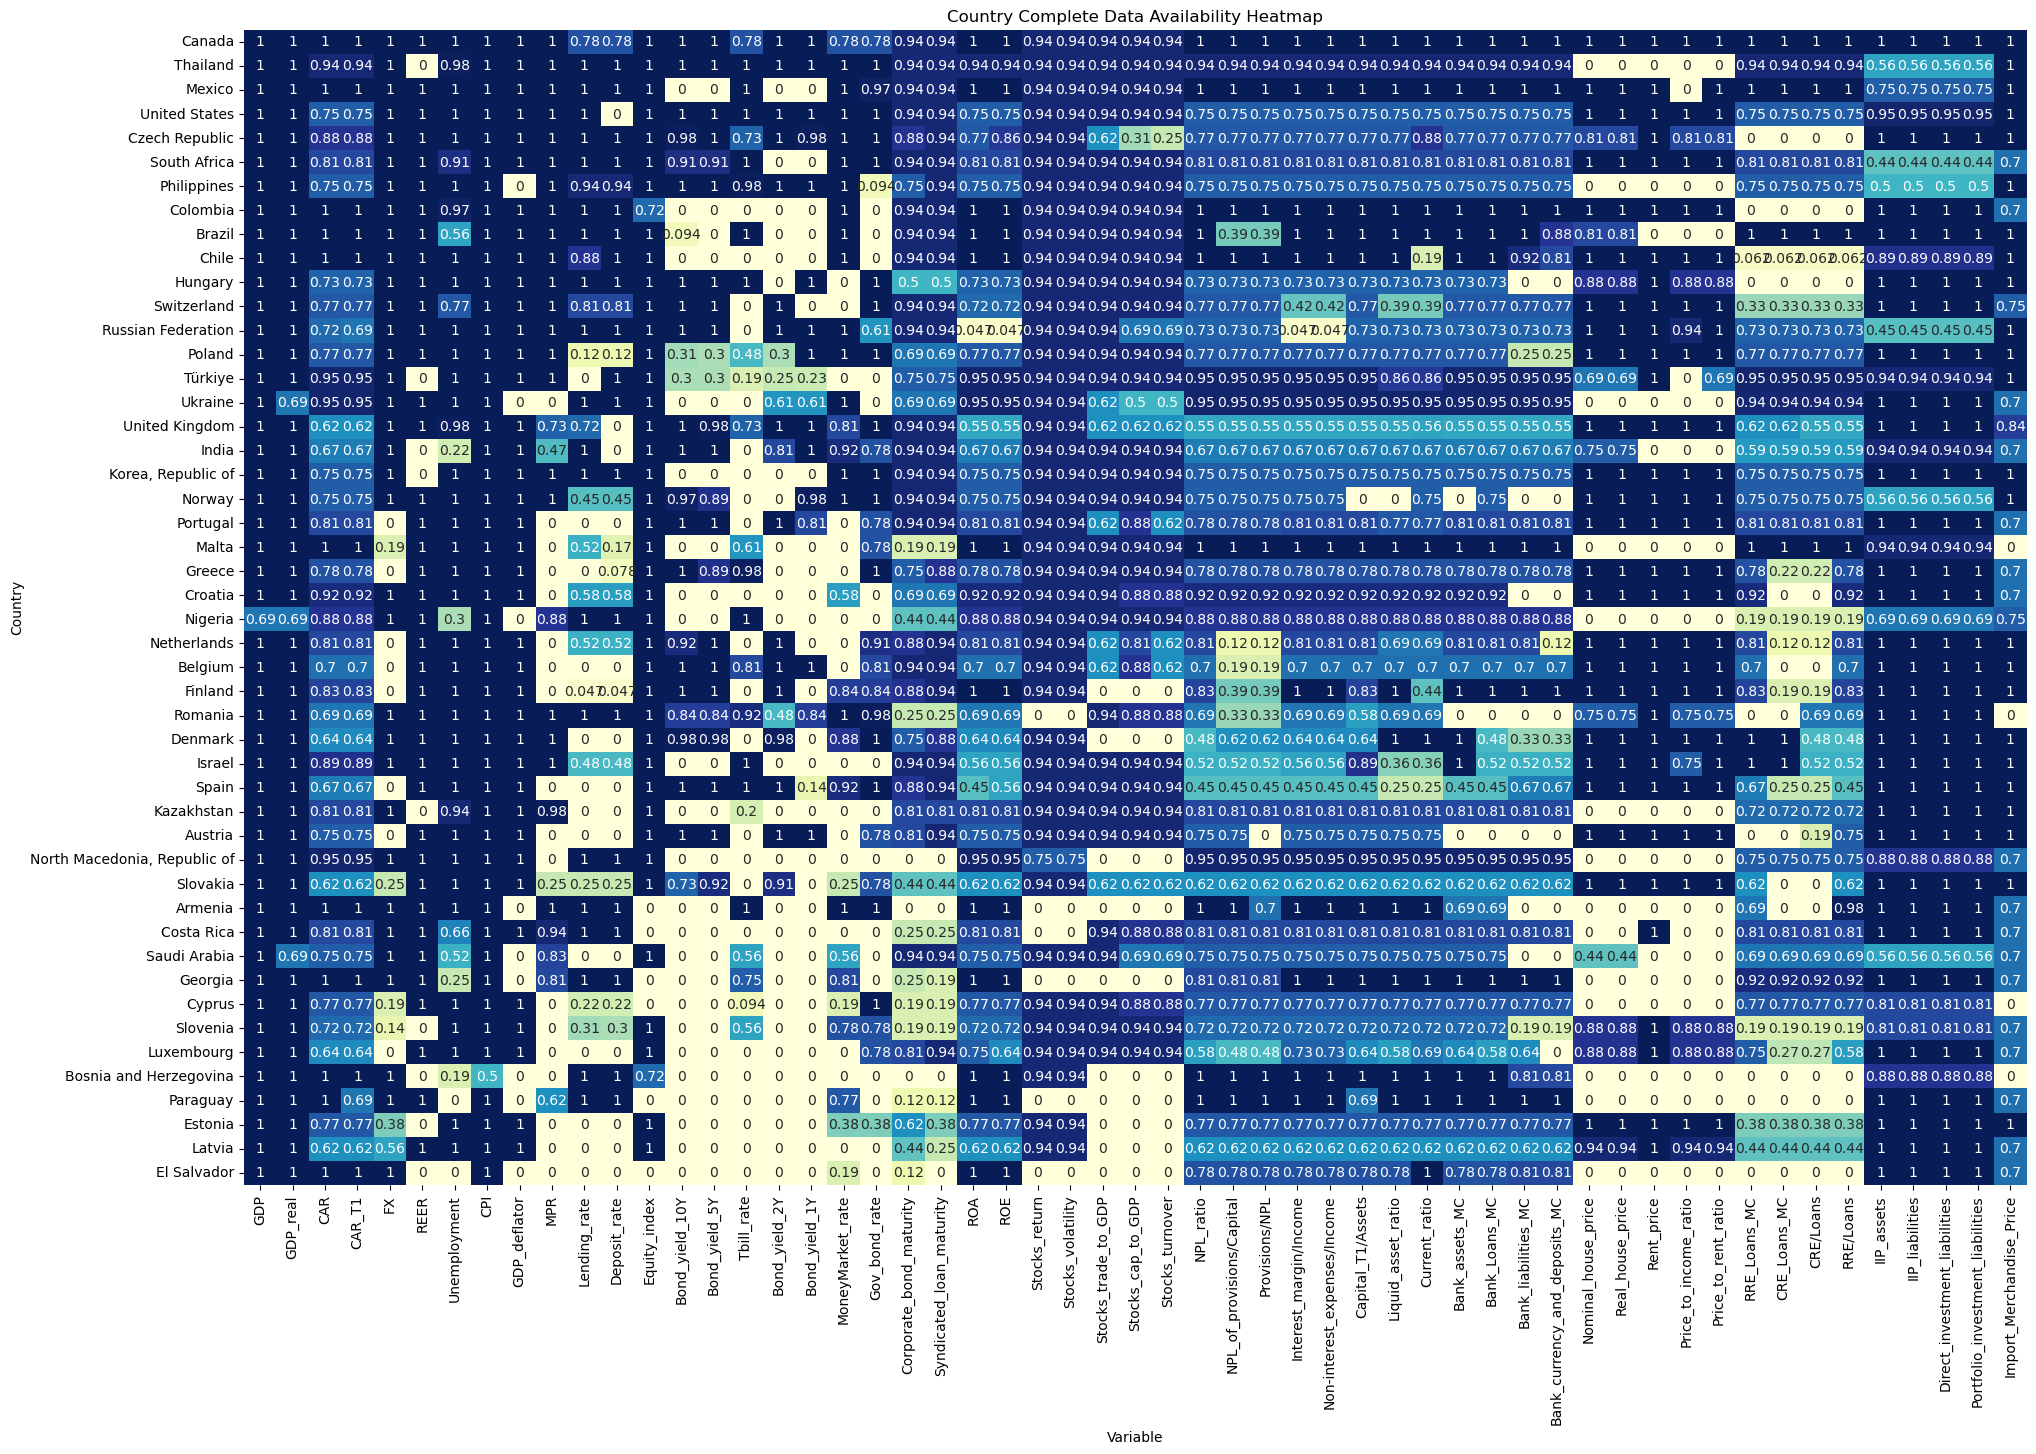

In [25]:
# availability calc (country)
n_main_variables = 40
data_availability_rc = (panel_dataset_complete.notna().groupby(
    panel_dataset_complete["country"]).mean().drop(["country", "date"], axis=1))
# variable_order = data_availability_rc.round().mean(axis=0).argsort()[::-1]
# data_availability_rc = data_availability_rc.iloc[:, variable_order]
country_order = (data_availability_rc.iloc[:, :n_main_variables].mean(
    axis=1).argsort()[::-1])
data_availability_rc = data_availability_rc.iloc[country_order, :]

# Set up the figure and plot the availability heatmap
fig, ax = plt.subplots(
    figsize=(23, 15))  # Adjust the figsize as needed to ensure visibility
sns.heatmap(data_availability_rc,
            cmap="YlGnBu",
            ax=ax,
            vmin=0,
            vmax=1,
            cbar=False,
            annot=True)

# Customize the plot
ax.set_title("Country Complete Data Availability Heatmap")
ax.set_xlabel("Variable")
ax.set_ylabel("Country")

# Display the plot
plt.show()

In [26]:
print("Missing:", data_availability_rc.sum().sum() / data_availability_rc.size)

Missing: 0.7086055871212121


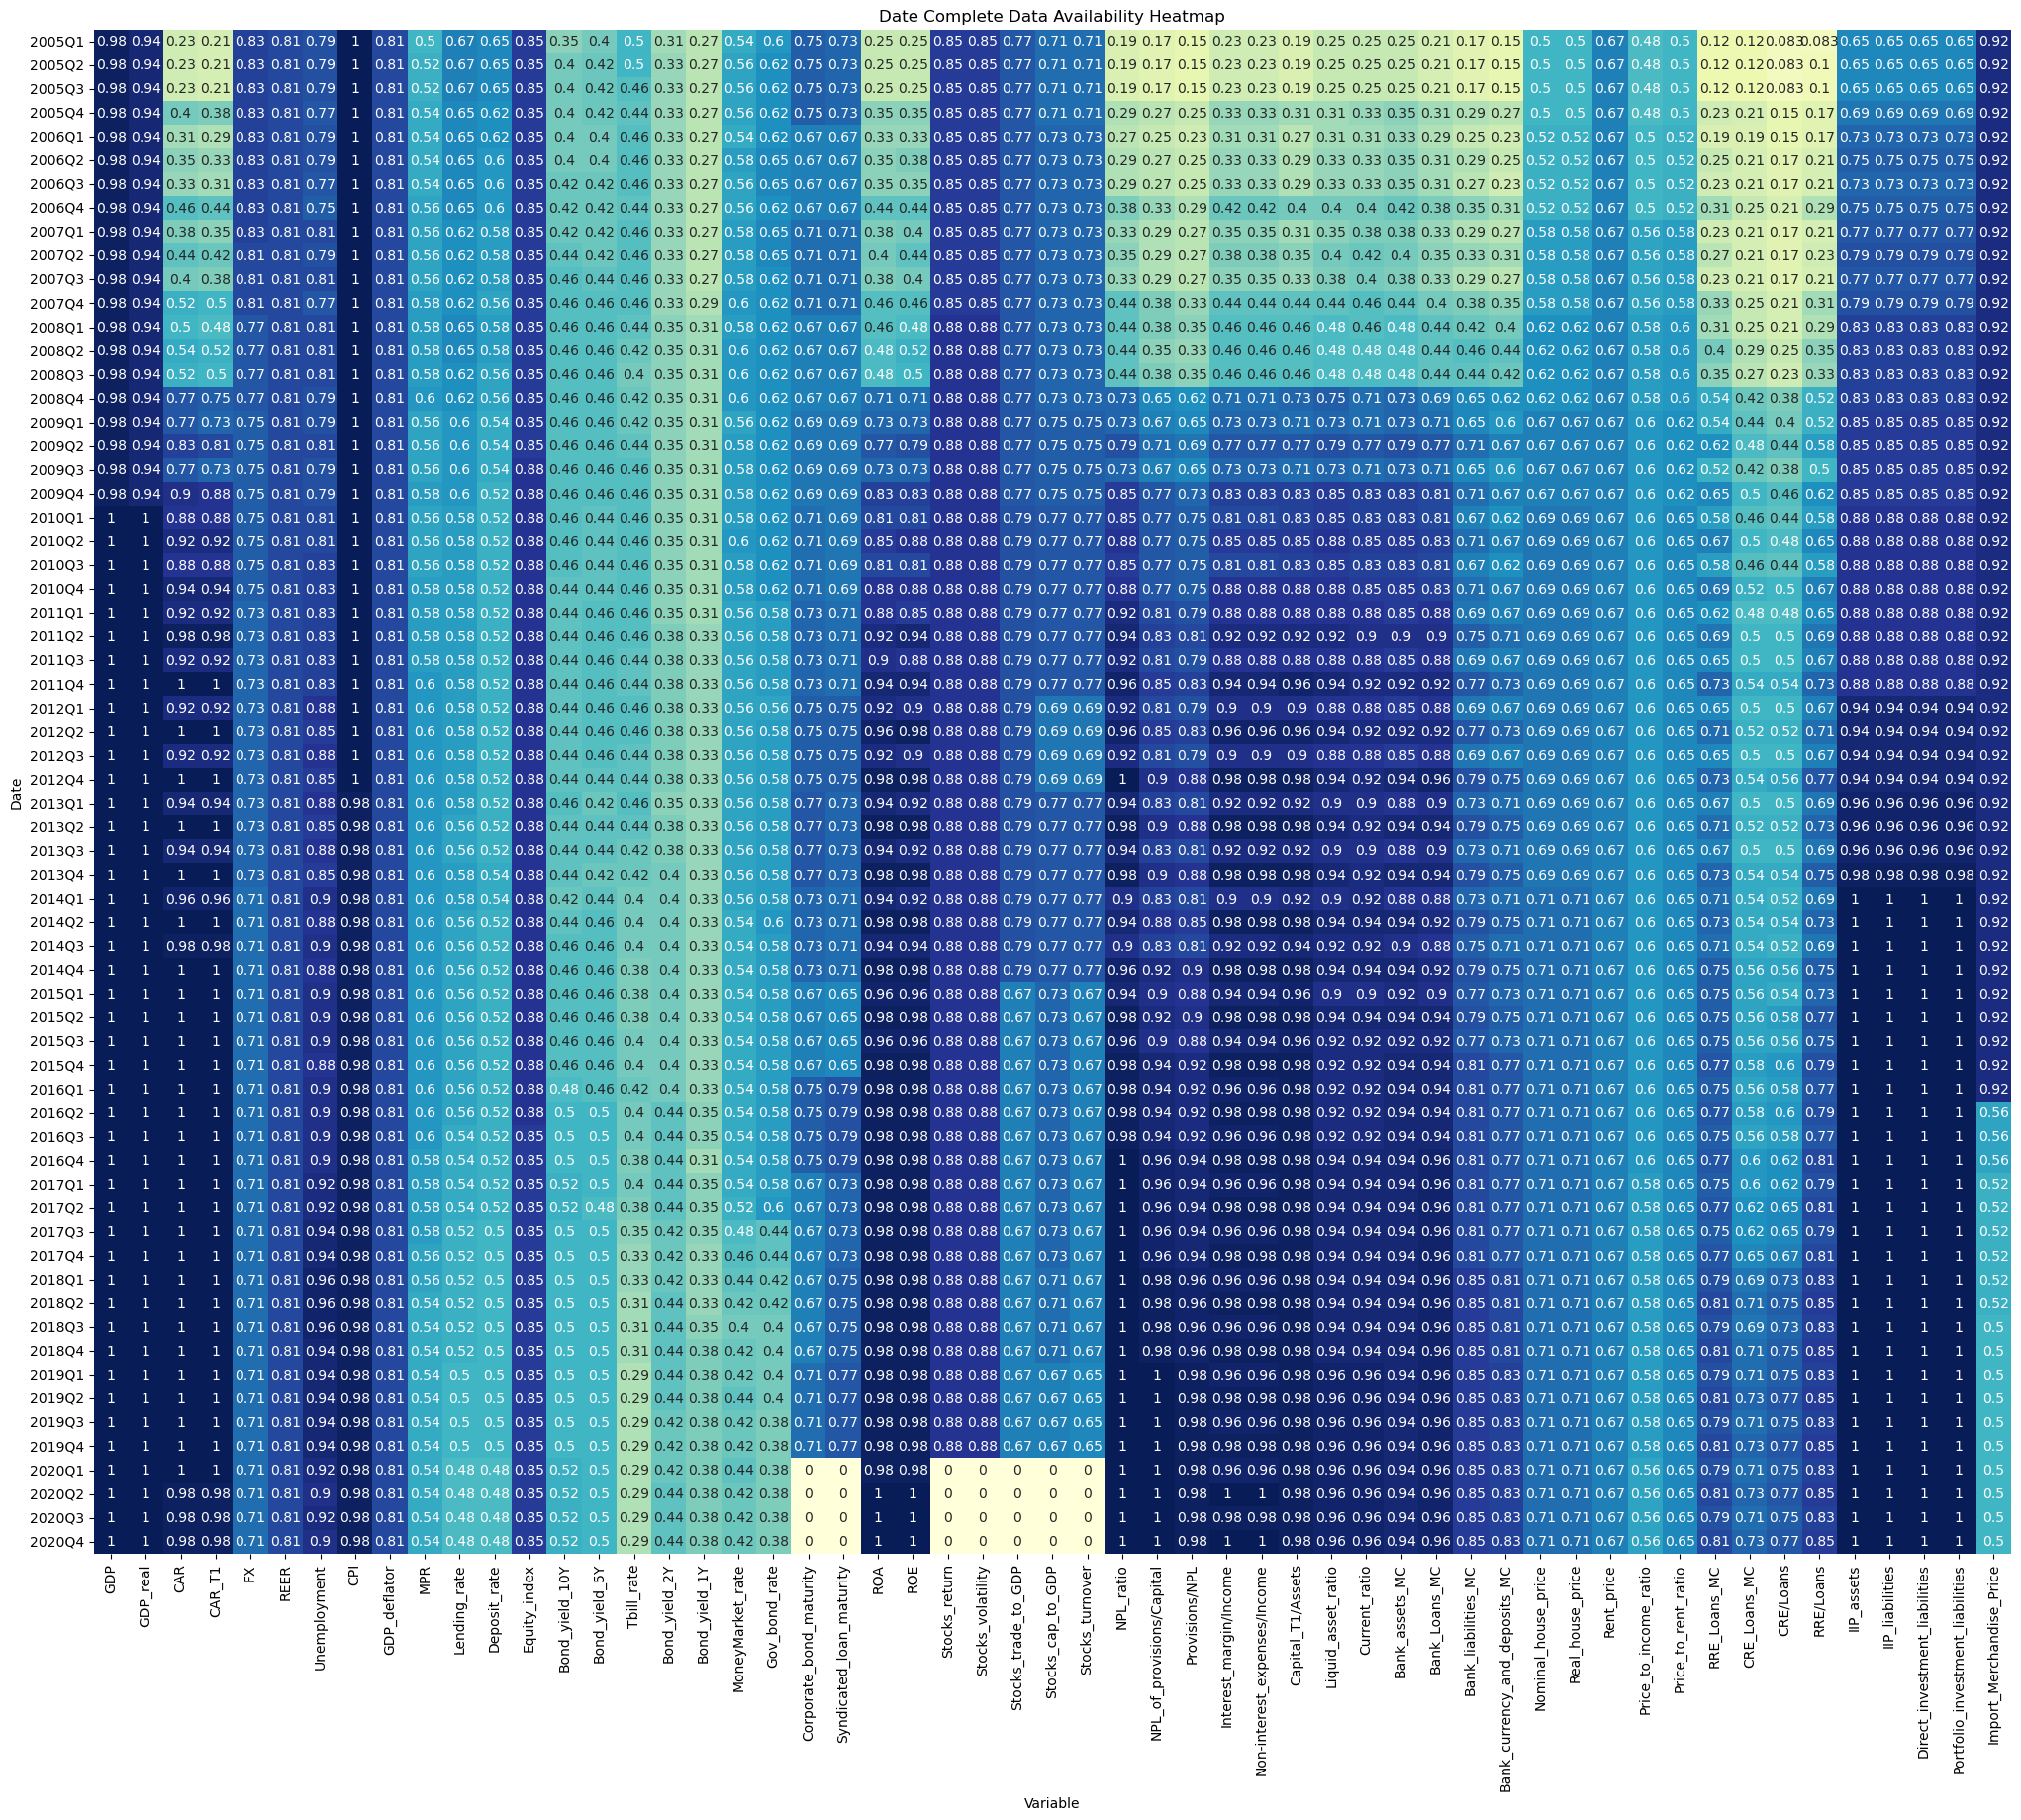

In [27]:
# availability calc (date)
data_availability_rd = (panel_dataset_complete.notna().groupby(
    panel_dataset_complete["date"]).mean().drop(["country", "date"], axis=1))
data_availability_rd.index = data_availability_rd.index.to_period("Q")
data_availability_rd = data_availability_rd[data_availability_rc.columns]

# Set up the figure and plot the availability heatmap
fig, ax = plt.subplots(
    figsize=(25, 20))  # Adjust the figsize as needed to ensure visibility
sns.heatmap(data_availability_rd,
            cmap="YlGnBu",
            ax=ax,
            vmin=0,
            vmax=1,
            cbar=False,
            annot=True)

# Customize the plot
ax.set_title("Date Complete Data Availability Heatmap")
ax.set_xlabel("Variable")
ax.set_ylabel("Date")

# Display the plot
plt.show()

# Consistency based transformations

In [38]:
wd_path = "./data/working_data/"
panel_dataset_complete = pd.read_csv(wd_path + "panel_dataset_complete.csv",
                                     parse_dates=["date"]).set_index(["country", "date"])

In [39]:
# calculating consistency scores before transformation
panel_countries = panel_dataset_complete.groupby("country")
cmeans = panel_countries.mean().median()
consistency_scores = panel_countries.agg(lambda x: consistencyScore(x, cmeans))
cs_before_by_var = consistency_scores.mean().sort_values()
cs_before_by_country = consistency_scores.mean(axis=1).sort_values()

In [40]:
# performing transformations
tf_func = lambda x: feature_engineering_pipeline.fit_transform(x.reset_index('country', drop=True))
panel_dataset_tf = panel_countries.apply(tf_func)

# grouping columns based on origin
original_columns = list(panel_dataset_complete.columns)
generated_sample = list(panel_countries[[original_columns[0]]].apply(tf_func).columns)
col_lookup = re.compile(f"{original_columns[0]}", re.IGNORECASE)
generated_suffixes = [col_lookup.sub('', s) for s in generated_sample]
column_group_mapping = {c+s: c for s in generated_suffixes for c in original_columns}
column_groups = {c: [c+s for s in generated_suffixes] for c in original_columns}

In [41]:
# calculating consistency scores after transformation
panel_countries = panel_dataset_tf.groupby("country")
cmeans = panel_countries.mean().median()
consistency_scores = panel_countries.agg(lambda x: consistencyScore(x, cmeans))
cs_after_by_var = consistency_scores.mean().sort_values()

# organizing variables by group
cs_after_by_var = cs_after_by_var.reset_index(name='score')
cs_after_by_var['original_column'] = cs_after_by_var['index'].replace(column_group_mapping)
cs_after_by_var = cs_after_by_var.set_index(['original_column', 'index'])
cs_after_by_var = cs_after_by_var.loc[[(o, c) for o, g in column_groups.items() for c in g]].copy()

In [42]:
# applying custom transformations
horizon = 4
target = 'GDP_real_hz_'+str(horizon)+'_growth'
autoregressive = 'GDP_real_growth'

# adding GDP growth rate to the transformations set
gdp_growth_series = panel_dataset_tf['GDP_real'].groupby('country')
panel_dataset_tf[autoregressive] = gdp_growth_series.pct_change(4, fill_method=None)*100
gdp_growth_series = gdp_growth_series.apply(calc_growth_rate, horizon=4, yearfreq=4, method_growth='cpd')
panel_dataset_tf[target] = gdp_growth_series.reset_index(0, drop=True)

In [43]:
# overviewing transformation consistency
display(cs_after_by_var.loc[original_columns[1]])

,score
index,
GDP_real,0.037304
GDP_real_lag_1,0.036877
GDP_real_lag_2,0.036448
GDP_real_lag_3,0.036530
GDP_real_lag_4,0.036531
GDP_real_log,0.036113
GDP_real_lag_1_log,0.035745
GDP_real_lag_2_log,0.035376
GDP_real_lag_3_log,0.035423


In [44]:
# # plotting correlation heatmap across countires
# wvar = 'Import_Merchandise_Price_PctC_4'
# corr = panel_dataset_tf[wvar].reset_index().pivot_table(wvar, 'date', 'country').corr()
# mask = np.triu(corr)
# fig, ax = plt.subplots(figsize=(20, 20))
# ax = sns.heatmap(corr, annot=True, ax=ax, cbar=False, annot_kws={"size": 8}, mask=mask)
# ax.set_title('correlation heatmap', fontsize=16)
# plt.show()

In [45]:
# sns.relplot(
#     data=panel_dataset_tf.reset_index(),
#     x="date", y=wvar,
#     col="country",
#     height=4, aspect=.7, kind="line",
#     facet_kws={'sharey': False}
# )
# plt.show()

In [46]:
# directional mismatch possible for:
# REER

# additional columns added:
# Lending_rate, Deposit_rate, Lending_rate_sin, Deposit_rate_sin,
# Stocks_volatility_PctC_4, Bank_assets_MC_cos, 
# Bank_currency_and_deposits_MC_cos, Nominal_house_price,
# Real_house_price, Import_Merchandise_Price

# Can't decide for:
# MPI, Equity_index, Tbill_rate, MoneyMarket_rate,
# Corporate_bond_maturity, Lending_rate, Deposit_rate

# dropping columns due to temporal or other model related issues
# NPL_of_provisions/Capital

to_normalize = [
    'Unemployment', 'Stocks_trade_to_GDP', 'Stocks_cap_to_GDP',
    'Stocks_turnover', 'Provisions/NPL', 'Capital_T1/Assets',
    'Liquid_asset_ratio', 'Current_ratio', 'CRE/Loans',
    'RRE/Loans'
]
consistent_columns = [
    target, autoregressive, 'CAR', 'CAR_T1', 'FX_PctC_4', 'REER',
    'Unemployment', 'CPI_PctC_4', 'GDP_deflator_PctC_4', 'MPR_PctC_4',
    'Lending_rate', 'Lending_rate_PctC_4', 'Lending_rate_sin', 'Deposit_rate',
    'Deposit_rate_PctC_4', 'Deposit_rate_sin', 'Equity_index', 'Bond_yield_10Y',
    'Bond_yield_5Y', 'Bond_yield_2Y', 'Bond_yield_1Y', 'Tbill_rate',
    'MoneyMarket_rate', 'Gov_bond_rate', 'Corporate_bond_maturity',
    'Syndicated_loan_maturity', 'ROA', 'ROE', 'Stocks_return',
    'Stocks_volatility', 'Stocks_volatility_PctC_4', 'Stocks_trade_to_GDP',
    'Stocks_cap_to_GDP', 'Stocks_turnover', 'NPL_ratio_PctC_4',
    'Provisions/NPL', 'Interest_margin/Income', 'Non-interest_expenses/Income',
    'Capital_T1/Assets', 'Liquid_asset_ratio', 'Current_ratio',
    'Bank_assets_MC_PctC_4', 'Bank_assets_MC_cos', 'Bank_Loans_MC_PctC_4',
    'Bank_liabilities_MC_PctC_4', 'Bank_currency_and_deposits_MC_PctC_4',
    'Bank_currency_and_deposits_MC_cos', 'Nominal_house_price', 
    'Nominal_house_price_PctC_4', 'Real_house_price', 'Real_house_price_PctC_4', 
    'Rent_price_PctC_4', 'Price_to_income_ratio', 'Price_to_rent_ratio', 
    'RRE_Loans_MC_PctC_4', 'CRE_Loans_MC_PctC_4', 'CRE/Loans', 'RRE/Loans', 
    'IIP_assets_PctC_4', 'IIP_liabilities_PctC_4',
    'Direct_investment_liabilities_PctC_4', 'Portfolio_investment_liabilities_PctC_4',
    'Import_Merchandise_Price', 'Import_Merchandise_Price_PctC_4'
]

In [47]:
# create the consistent dataset and normazlie required columns
mm = MinMaxScalerDF()
panel_dataset_consistent = panel_dataset_tf[consistent_columns].copy()
norm_data = panel_dataset_consistent.loc[:, to_normalize].groupby('country').apply(lambda x: mm.fit_transform(x))
panel_dataset_consistent.loc[:, to_normalize] = norm_data.reset_index(0, drop=True)
panel_dataset_consistent.rename(columns={c: c+'_normalized' for c in to_normalize}, inplace=True)
panel_dataset_consistent = panel_dataset_consistent.sort_index().groupby('country')
panel_dataset_consistent = panel_dataset_consistent.apply(lambda x: x.iloc[:-4]).reset_index(0, drop=True)

In [51]:
# calculating consistency scores (final)
panel_countries = panel_dataset_consistent.groupby("country")
cmeans = panel_countries.mean().median()
consistency_scores = panel_countries.agg(lambda x: consistencyScore(x, cmeans))
cs_final_by_var = consistency_scores.mean().sort_values()
cs_final_by_country = consistency_scores.mean(axis=1).sort_values()

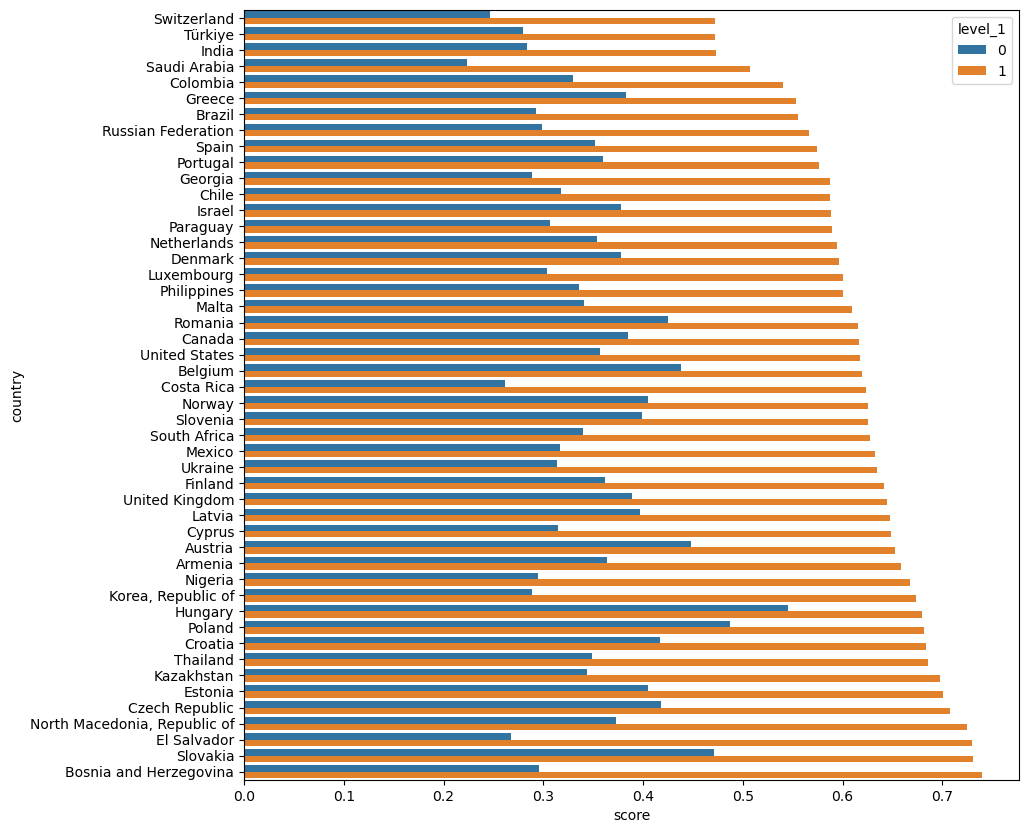

In [49]:
cs_change = pd.concat([cs_before_by_country, cs_final_by_country], axis=1)
cs_change = cs_change.stack().reset_index(name='score')

fig, ax = plt.subplots(figsize=(10, 10))
ax = sns.barplot(cs_change, x="score", y="country", hue='level_1', 
                 order=cs_final_by_country.index, orient='h', ax=ax)
plt.show()

In [62]:
wd_path = "./data/working_data/"
panel_dataset_consistent.to_csv(wd_path + "panel_dataset_consistent.csv", index=True)

# Data quality review 2

In [28]:
wd_path = "./data/working_data/"
panel_dataset_consistent = pd.read_csv(wd_path + "panel_dataset_consistent.csv",
                                       parse_dates=["date"])
panel_dataset = pd.read_csv(wd_path + "panel_dataset.csv", parse_dates=["date"])

# setting indices
panel_dataset_consistent = panel_dataset_consistent.set_index(["country", "date"])
panel_dataset = panel_dataset.set_index(["country", "date"])

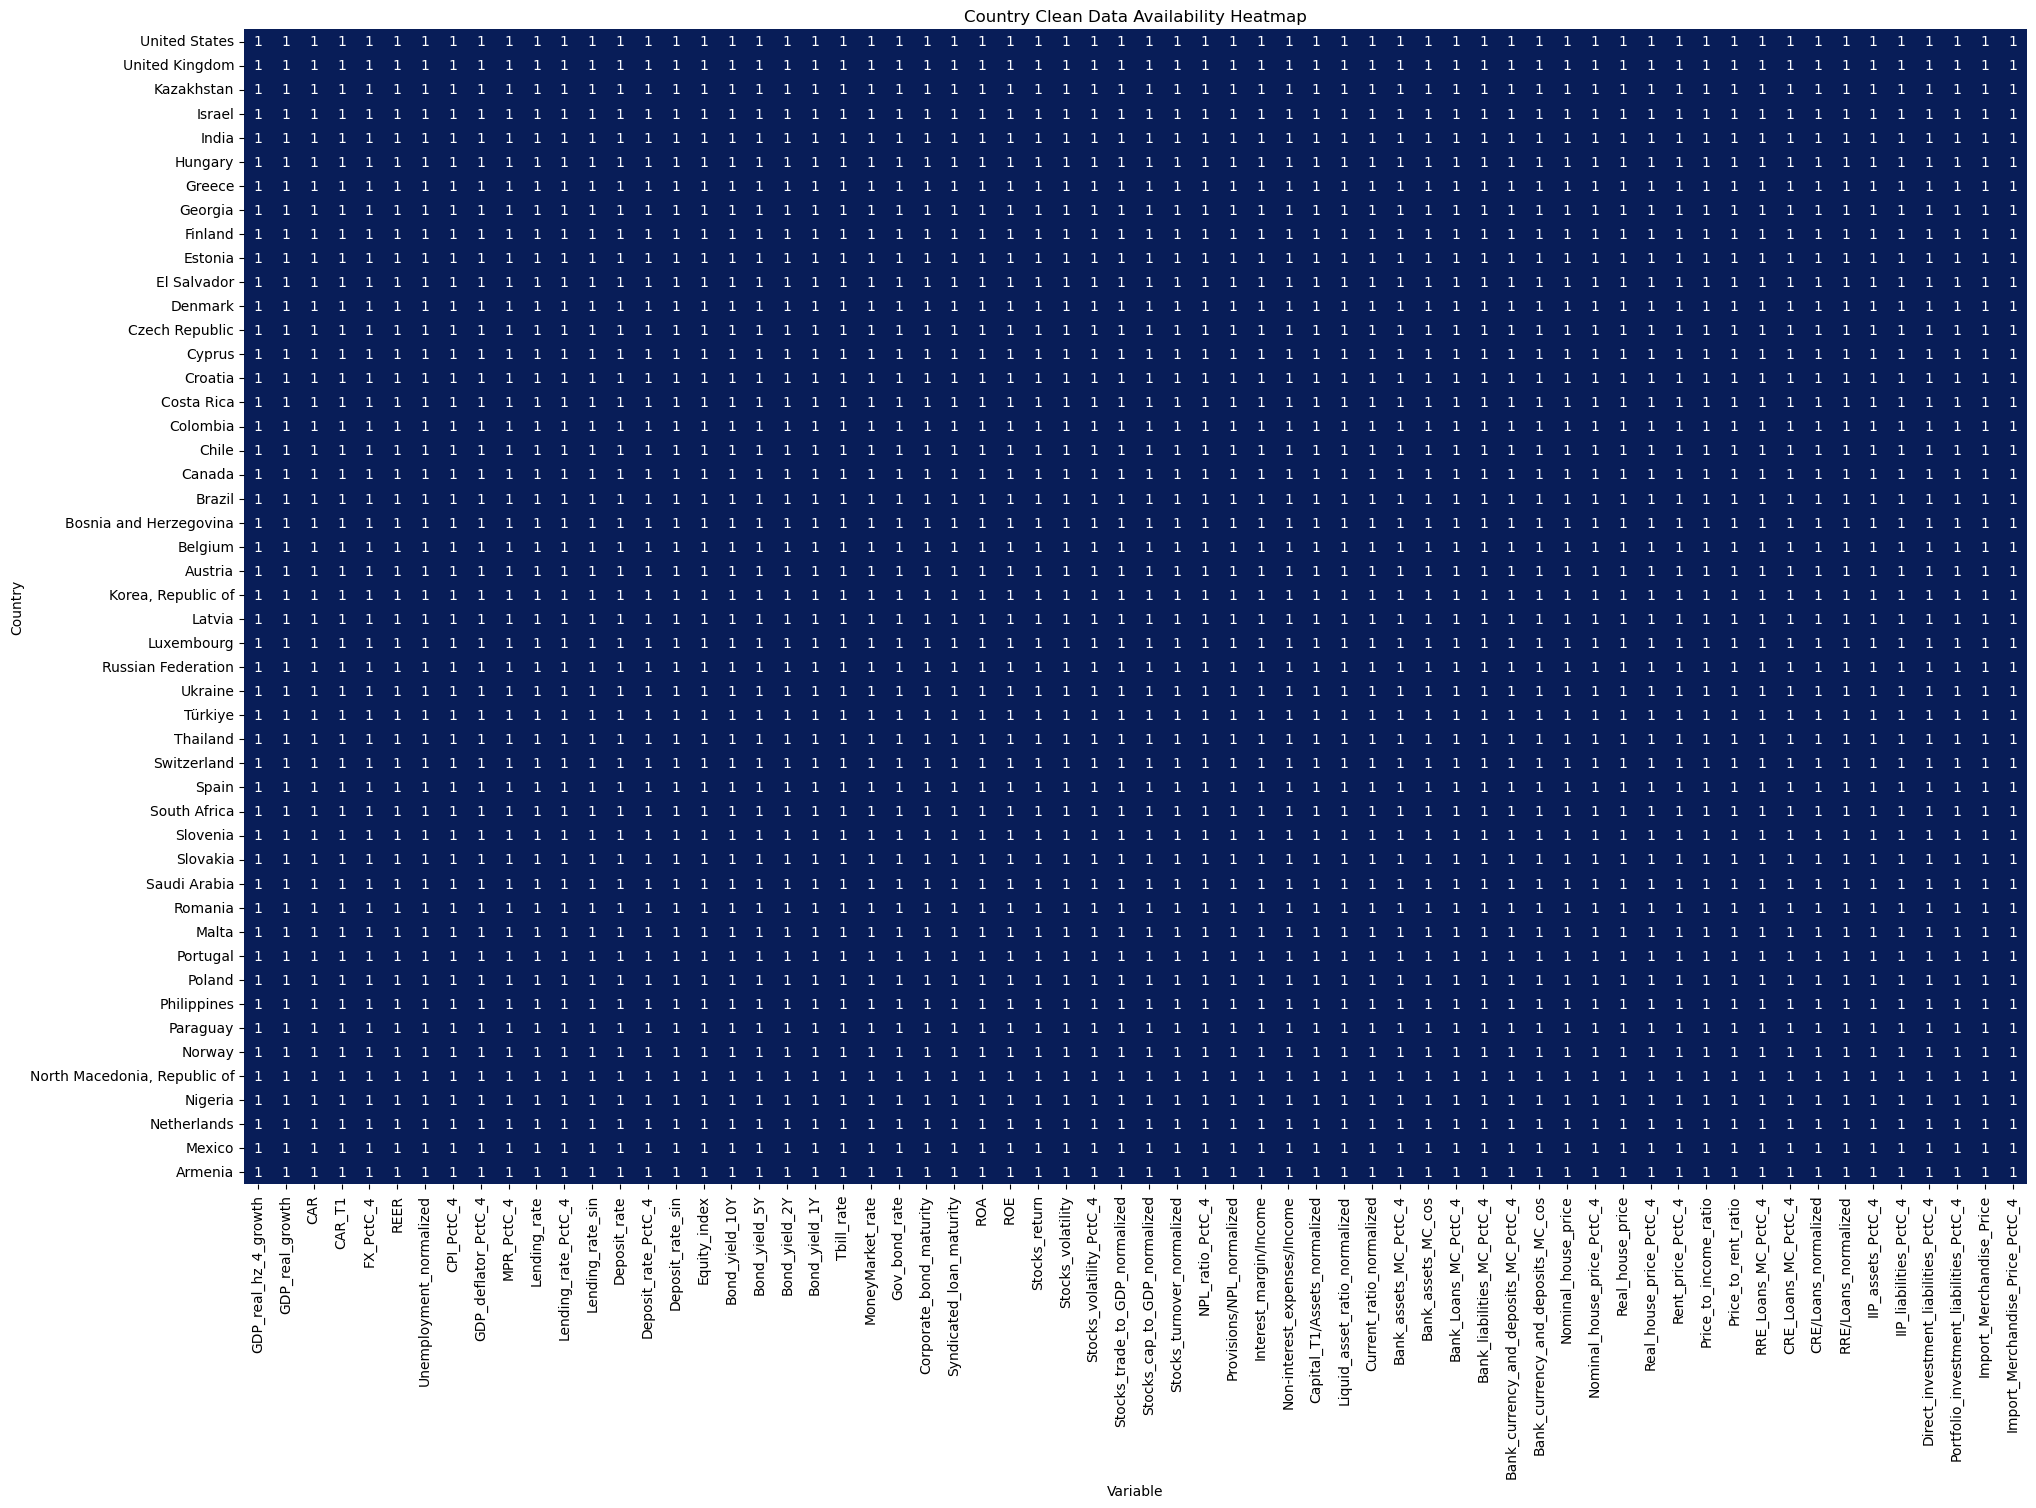

In [29]:
# availability calc (country)
n_main_variables = 40
data_availability_rc_expanded = (panel_dataset.reset_index().notna().groupby(
    panel_dataset.reset_index()["country"]).mean().drop(["country", "date"],
                                                        axis=1))
country_order = (data_availability_rc_expanded.iloc[:, :n_main_variables].mean(
    axis=1).argsort()[::-1])
data_availability_rc_extended = data_availability_rc_expanded.iloc[
    country_order, :]

# Set up the figure and plot the availability heatmap
fig, ax = plt.subplots(
    figsize=(23, 15))  # Adjust the figsize as needed to ensure visibility
sns.heatmap(
    data_availability_rc_extended,
    cmap="YlGnBu",
    ax=ax,
    vmin=0,
    vmax=1,
    cbar=False,
    annot=True,
)

# Customize the plot
ax.set_title("Country Clean Data Availability Heatmap")
ax.set_xlabel("Variable")
ax.set_ylabel("Country")

# Display the plot
plt.show()

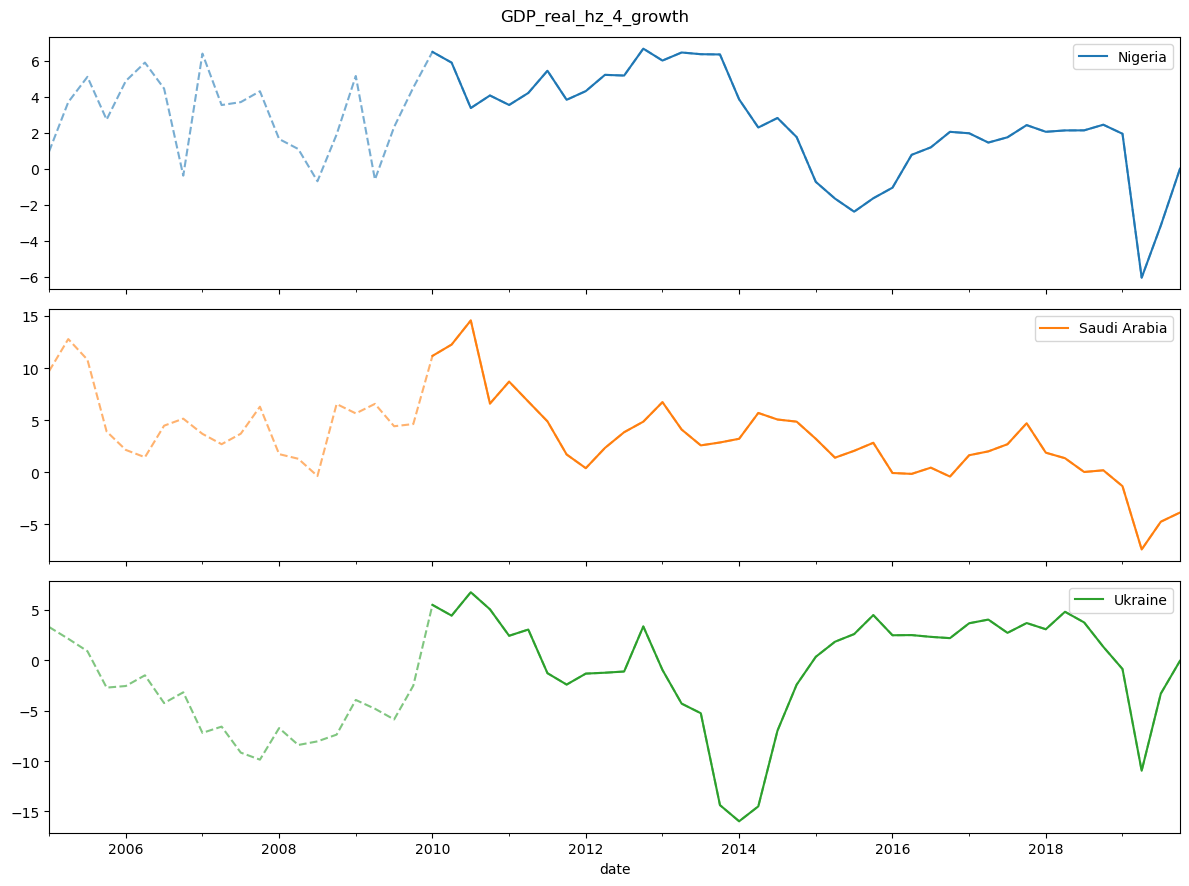

In [31]:
observed_variable = "GDP_real_hz_4_growth"
series_missing = panel_dataset_consistent.reset_index().pivot(
    index="date", columns=["country"], values=observed_variable)
series_filled = panel_dataset.reset_index().pivot(index="date",
                                                  columns=["country"],
                                                  values=observed_variable)
some_missing_columns = series_missing.columns[series_missing.isna().any()]
fig_scale = 6 + len(some_missing_columns)

fig, axes = plt.subplots(nrows=len(some_missing_columns),
                         ncols=1,
                         figsize=(12, fig_scale),
                         sharex=True)
series_missing[some_missing_columns].plot(ax=axes, subplots=True, legend=True)
series_filled[some_missing_columns].plot(ax=axes,
                                         subplots=True,
                                         style="--",
                                         alpha=0.6,
                                         legend=False)
plt.suptitle(observed_variable)
plt.tight_layout()
plt.show()

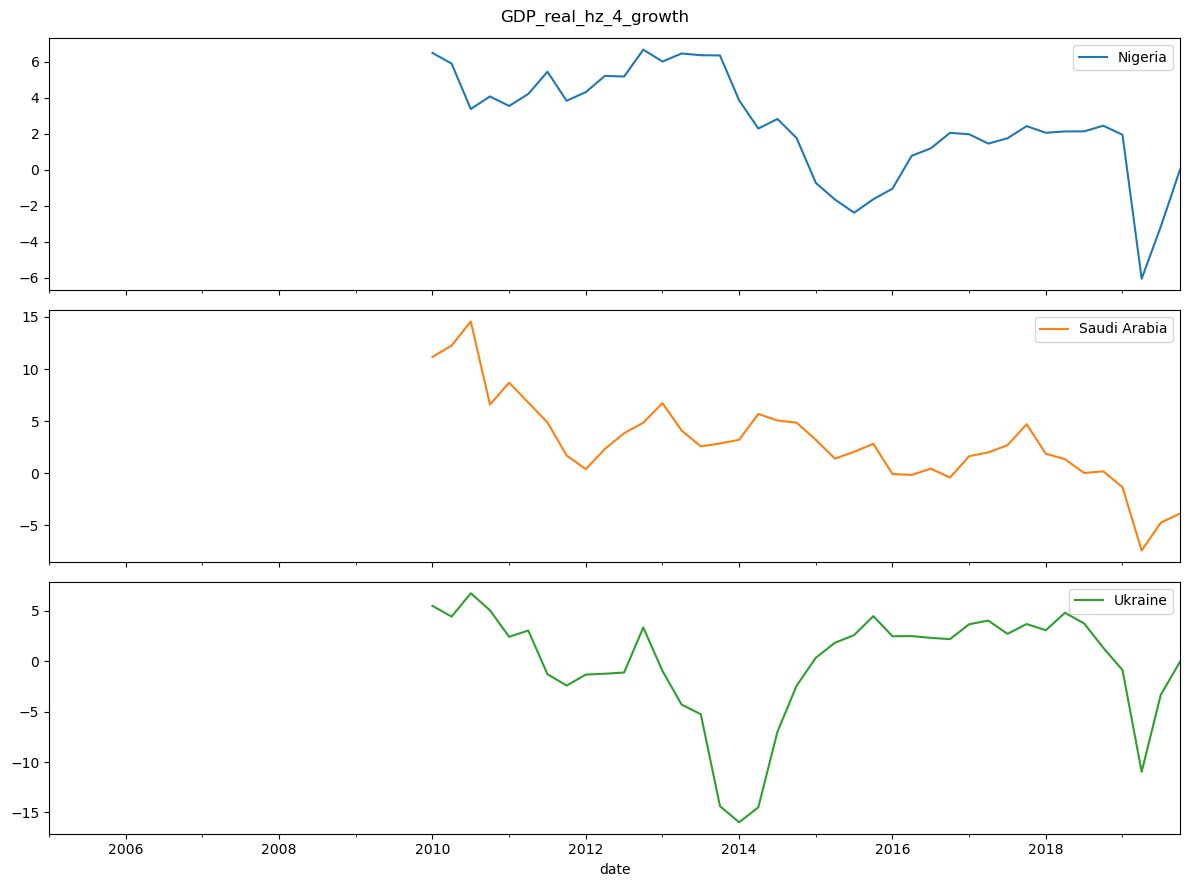

In [32]:
fig, axes = plt.subplots(nrows=len(some_missing_columns),
                         ncols=1,
                         figsize=(12, fig_scale),
                         sharex=True)
series_missing[some_missing_columns].plot(ax=axes, subplots=True, legend=True)
plt.suptitle(observed_variable)
plt.tight_layout()
plt.show()

In [33]:
display(panel_dataset.groupby("country").mean(numeric_only=True).min())

GDP_real_hz_4_growth                       -1.681922
GDP_real_growth                            -0.750493
CAR                                        12.465648
CAR_T1                                      9.320545
FX_PctC_4                                  -0.086515
                                             ...    
IIP_liabilities_PctC_4                      0.022456
Direct_investment_liabilities_PctC_4        0.007992
Portfolio_investment_liabilities_PctC_4    -0.759089
Import_Merchandise_Price                    0.770449
Import_Merchandise_Price_PctC_4            -0.065530
Length: 64, dtype: float64

In [34]:
display(panel_dataset.groupby("country").mean(numeric_only=True)["Lending_rate"])

country
Armenia                         16.581047
Austria                          6.856500
Belgium                          7.449521
Bosnia and Herzegovina           6.568041
Brazil                          42.750222
Canada                           3.652414
Chile                            7.333449
Colombia                        12.781657
Costa Rica                      15.589361
Croatia                          9.584753
Cyprus                           5.128994
Czech Republic                   5.002316
Denmark                          8.081525
El Salvador                     12.404565
Estonia                         11.534067
Finland                          2.673111
Georgia                         14.486105
Greece                          11.095507
Hungary                          6.154749
India                           10.669806
Israel                           5.335560
Kazakhstan                      11.221980
Korea, Republic of               4.933833
Latvia                    

In [35]:
display(panel_dataset.groupby("country").mean(numeric_only=True))

,GDP_real_hz_4_growth,GDP_real_growth,CAR,CAR_T1,FX_PctC_4,REER,Unemployment_normalized,CPI_PctC_4,GDP_deflator_PctC_4,MPR_PctC_4,...,RRE_Loans_MC_PctC_4,CRE_Loans_MC_PctC_4,CRE/Loans_normalized,RRE/Loans_normalized,IIP_assets_PctC_4,IIP_liabilities_PctC_4,Direct_investment_liabilities_PctC_4,Portfolio_investment_liabilities_PctC_4,Import_Merchandise_Price,Import_Merchandise_Price_PctC_4
country,,,,,,,,,,,,,,,,,,,,,
Armenia,4.136005,5.320232,22.664429,20.620969,0.011226,97.817062,0.415897,0.038048,0.058891,0.069614,...,0.247278,0.222485,0.411668,0.535303,0.136146,0.129359,0.102950,1.932754,1.036624,0.021733
Austria,0.907849,1.593089,16.134034,12.512889,-0.012158,101.234827,0.477558,0.018161,0.017388,-0.715944,...,0.124273,-0.026884,0.223987,0.494508,0.046022,0.035757,0.075034,0.152046,0.932773,-0.003582
Belgium,1.052135,1.617196,17.230211,14.548402,-0.034161,100.177563,0.683194,0.018463,0.015708,-0.511933,...,0.033476,0.057221,0.586653,0.501244,0.049848,0.048512,0.098985,0.142664,1.098517,0.033288
Bosnia and Herzegovina,2.219524,2.618412,16.546561,14.097333,0.010461,100.952410,0.622099,0.022544,0.033847,-0.232036,...,0.143166,0.100681,0.506208,0.417027,0.087557,0.092449,0.154349,0.293567,1.031829,-0.001532
Brazil,1.755011,2.116771,17.412488,13.813706,0.054417,83.486830,0.319296,0.057922,0.072177,-0.019807,...,0.266187,0.189335,0.507935,0.453608,0.140829,0.111856,0.137985,0.023848,1.042641,0.017979
Canada,1.357617,1.947005,14.736326,12.028666,0.011592,91.728433,0.205586,0.017391,0.018013,0.220579,...,0.094549,0.109312,0.664310,0.480966,0.095960,0.079010,0.078455,0.090059,1.002409,0.011787
Chile,2.749480,3.491952,13.307445,10.161574,0.018094,96.889858,0.210647,0.032068,0.043650,0.346736,...,0.125424,0.043181,0.285838,0.384341,0.122948,0.115142,0.164842,0.482439,0.992094,0.003457
Colombia,3.191833,4.140948,17.347026,12.875423,0.030027,88.658744,0.210997,0.040843,0.045347,0.018437,...,0.118687,0.019106,0.138792,0.492866,0.132818,0.122257,0.158066,0.119075,1.000067,0.019190
Costa Rica,3.529820,3.965367,16.532849,12.815064,0.018058,100.735591,0.138376,0.054469,0.061825,0.071820,...,0.147065,0.060415,0.346762,0.608477,0.125019,0.129865,0.143819,0.222590,1.023186,0.003570


In [36]:
# calibrated imputer below
empty_imputer = EmptySeriesImputer(
    fill_method="country",
    scaler=None,
    recursive_imputation=False,
    aggregate_by="mean",
    alternative_priority_bias=False,
    partial_replica=True,
    recursive_replication=True,
)

# # making a stacked version of the dataset
# pd_m = panel_dataset_complete.set_index(['country', 'date']).isna().groupby('country').all()
# pd_m.columns.name = 'variable'
# pd_m = pd_m.stack()
# pd_m.name = 'missing'
# pd_m = pd_m.reset_index()

# pdexp = panel_dataset.set_index(['country', 'date']).groupby('country', group_keys=False).apply(empty_imputer.standardize_series)
# pdexp.columns.name = 'variable'
# pdexp = pdexp.stack()
# pdexp.name = 'value'
# pdexp = pdexp.reset_index()
# pdexp = pd.merge(pdexp, pd_m, 'left', ['country', 'variable'])

# # exporting pdexp
# res_path = './data/results/'
# pdexp.to_csv(res_path+'pdexp.csv', index=False)

In [37]:
corr1 = empty_imputer.flat_corr(panel_dataset_consistent)
corr2 = empty_imputer.flat_corr(panel_dataset)
loss = empty_imputer.fnorm(corr1, corr2)
ratio_of_na_cells = panel_dataset_consistent.unstack(
    level="country").isna().any().sum()
non_empty_corr_cells = corr1.size - ratio_of_na_cells * corr1.shape[0]
print("Replica loss:", loss)
print("Pseudo R2:", 1 - (loss / ((0.5**2) * non_empty_corr_cells)))

Replica loss: 749.8746824898737
Pseudo R2: 0.9987749067425863


/Users/victoryerz/anaconda3/lib/python3.11/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


# Adding MaPP dataset

In [26]:
# Integrated Macroprudential Policy
mapp_names = {"Country": "country", "iso3": "country code"}
mapp = pd.read_excel("./data/iMaPP/iMaPP_database.xlsx", sheet_name="MaPP")
mapp["date"] = pd.to_datetime(mapp["Year"].astype(str) + "-" +
                              mapp["Month"].astype(str),
                              format="%Y-%m")
mapp.set_index("date", inplace=True)
mapp.rename(columns=mapp_names, inplace=True)

# defining the rename mapping of countries and their codes
iso3_rev = {v: i for i, v in country_name_mapping_imf_to_iso3.items()}
mapp_codes = dict(zip(mapp["country code"], mapp["country"]))
mapp_codes = {
    i: v if i not in iso3_rev.keys() else iso3_rev[i]
    for i, v in mapp_codes.items()
}

mapp["country"] = mapp["country code"].replace(mapp_codes)
mapp.drop(
    columns=["country code", "ifscode", "iso2", "AE", "EMDE", "Year", "Month"],
    inplace=True,
)
mapp.index = mapp.index.to_period("Q")
mapp = mapp.groupby(["date", "country"]).sum().reset_index("country")
mapp.index = mapp.index.to_timestamp()
mapp = mapp.reset_index().set_index(["country", "date"])
# adding the capital based col
mapp["Capital_based"] = (mapp["CCB"] + mapp["Conservation"] + mapp["Capital"])

# defining the MPI columns
rolling_table = mapp.groupby("country").rolling(window=4, min_periods=1)
mapp["MPI"] = rolling_table["SUM_17"].sum().reset_index(0, drop=True)
mapp["MPI_capital"] = rolling_table["Capital_based"].sum().reset_index(
    0, drop=True)
mapp["MPI_CCyB"] = rolling_table["CCB"].sum().reset_index(0, drop=True)

# selecting MPI columns
mapp = mapp[["MPI", "MPI_capital", "MPI_CCyB"]].copy()

In [27]:
wd_path = "./data/working_data/"
panel_dataset = pd.read_csv(wd_path + "panel_dataset.csv", parse_dates=["date"])
panel_dataset = panel_dataset.set_index(["country", "date"])
panel_dataset = pd.merge(panel_dataset,
                         mapp,
                         how="left",
                         on=["country", "date"])

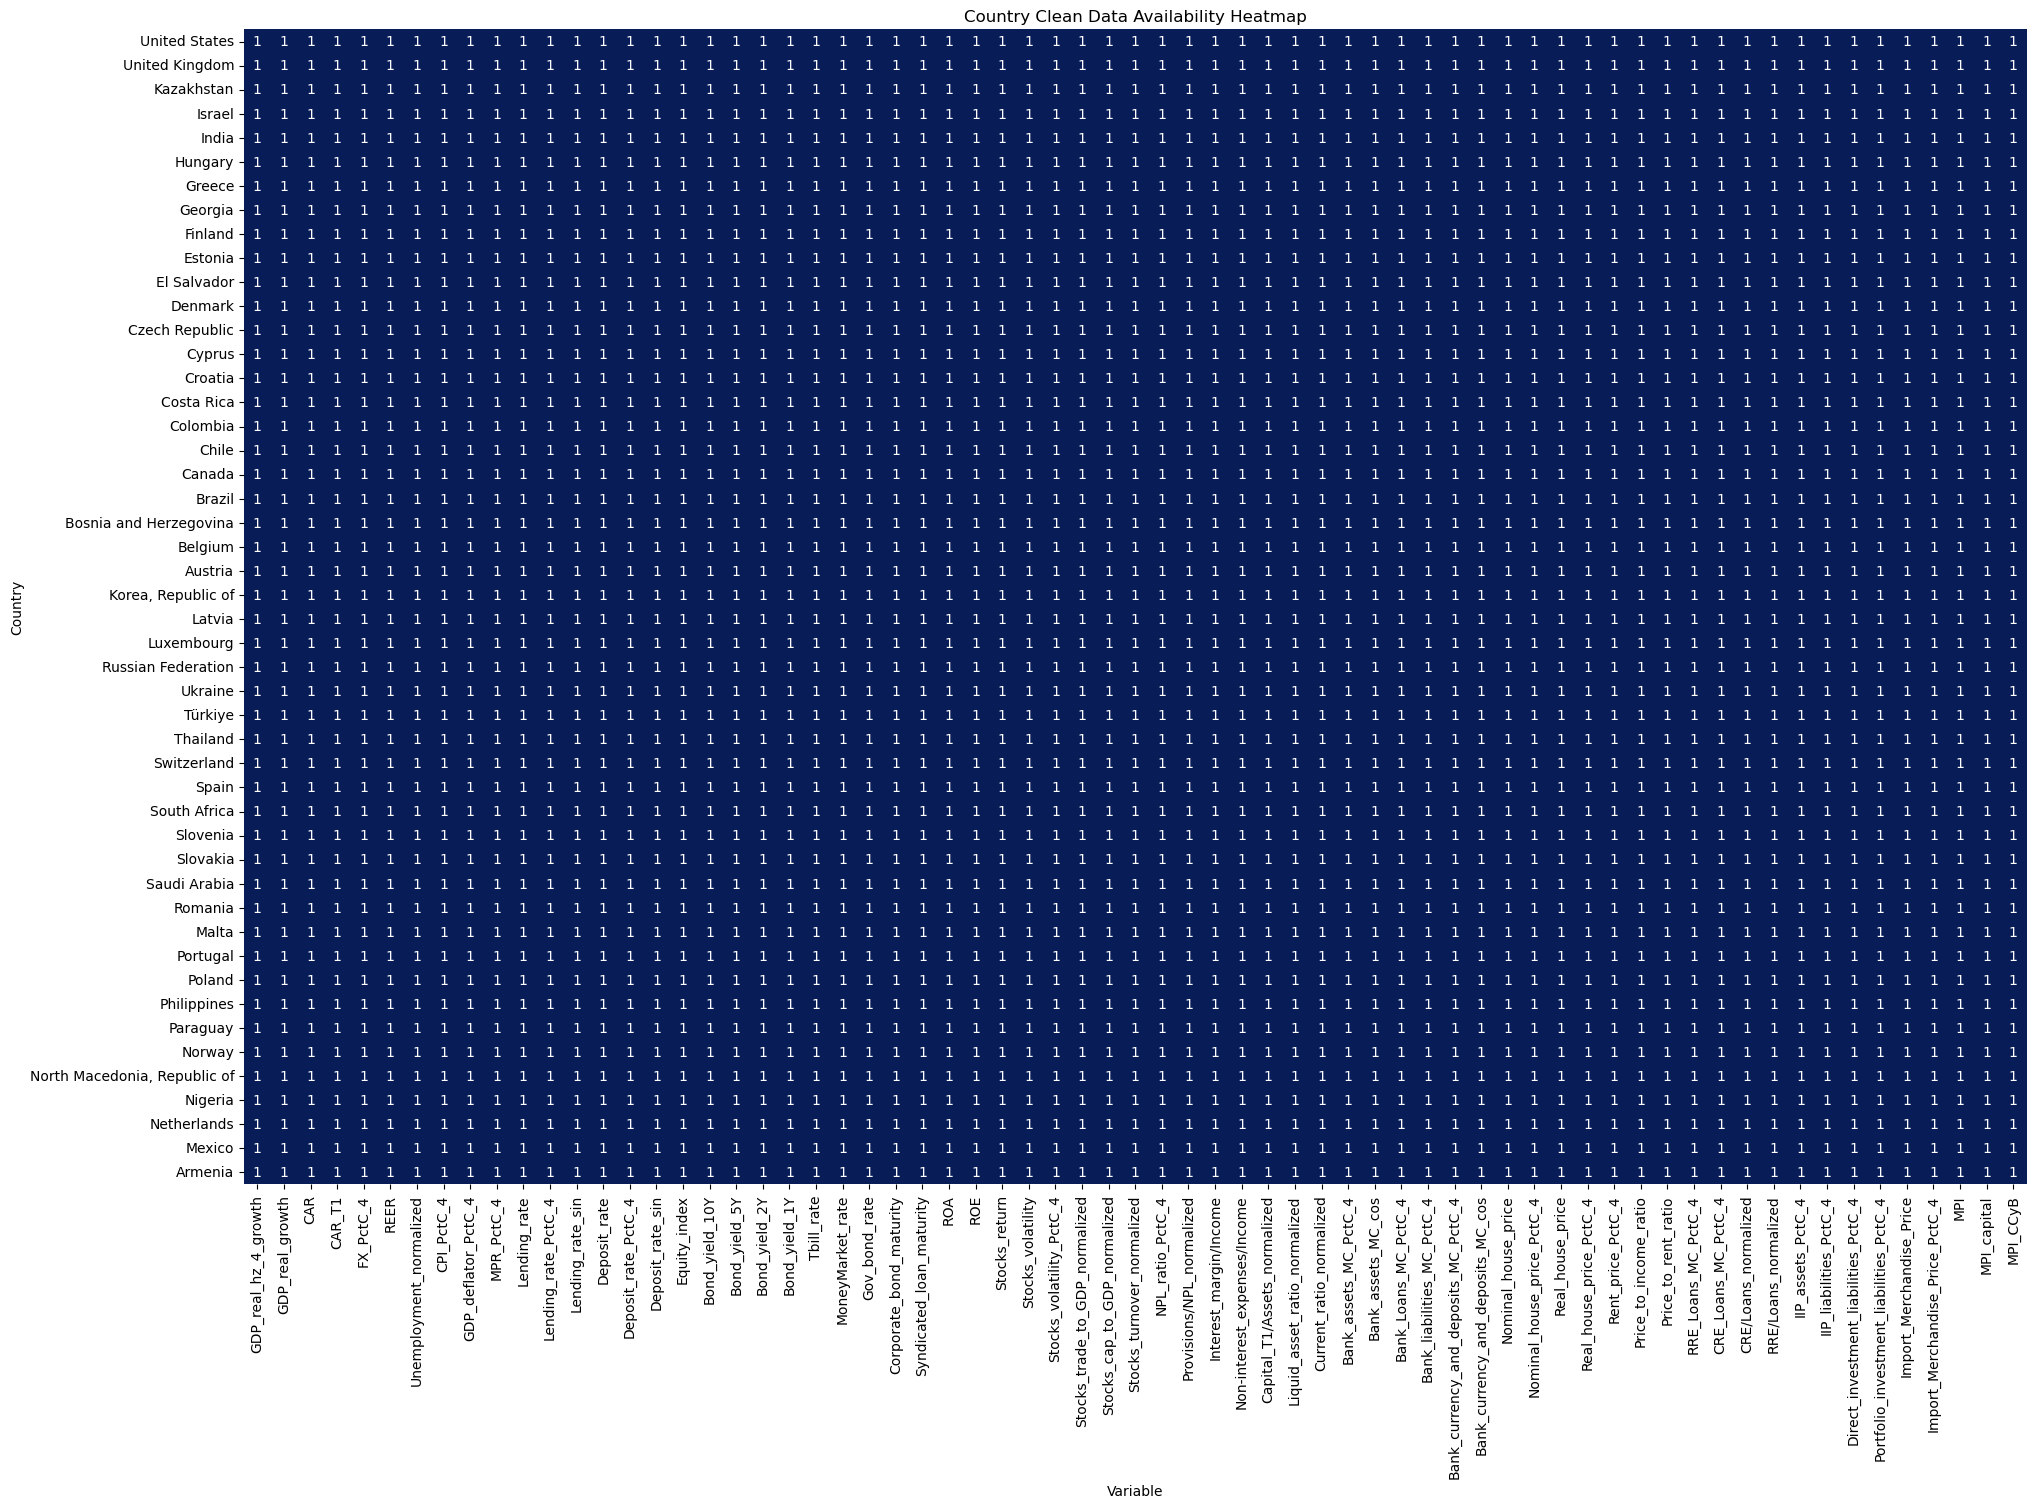

In [28]:
# availability calc (country)
n_main_variables = 40
data_availability_rc_expanded = (panel_dataset.reset_index().notna().groupby(
    panel_dataset.reset_index()["country"]).mean().drop(["country", "date"],
                                                        axis=1))
country_order = (data_availability_rc_expanded.iloc[:, :n_main_variables].mean(
    axis=1).argsort()[::-1])
data_availability_rc_extended = data_availability_rc_expanded.iloc[
    country_order, :]

# Set up the figure and plot the availability heatmap
fig, ax = plt.subplots(
    figsize=(23, 15))  # Adjust the figsize as needed to ensure visibility
sns.heatmap(
    data_availability_rc_extended,
    cmap="YlGnBu",
    ax=ax,
    vmin=0,
    vmax=1,
    cbar=False,
    annot=True,
)

# Customize the plot
ax.set_title("Country Clean Data Availability Heatmap")
ax.set_xlabel("Variable")
ax.set_ylabel("Country")

# Display the plot
plt.show()

In [29]:
# saving the final dataset to the GaR project data directory
gdata_path = "../data/panel_data/"
panel_dataset.to_csv(gdata_path + "panel_dataset.csv")